# Machine Learning Prep: Load Reaction Databases

This notebook prepares data for the Random Forest analysis requested in the revisions. For now, we will:

- Locate and load all filtered reaction databases for multimer sizes 4 and 5.
- Provide concise previews to verify successful loading.
- Add placeholders to later ingest band intensity Excel files.

Each step is documented with a short markdown cell for clarity.

# Imports and display options

We import standard data libraries and set display preferences for quick inspection.

In [28]:
# Import Required Libraries
import sys
import warnings
from pathlib import Path
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)

# Define paths and locate the filtered reaction databases

We resolve the repository root robustly (independent of current working directory) and point to `back_end/data/filtered_reaction_database`.

In [29]:
# Robustly find repository root and filtered data directory

def find_repo_root(start: Path) -> Path:
    """Ascend from start until we find a directory containing 'requirements.txt' and 'back_end'."""
    cur = start.resolve()
    for _ in range(10):  # guard against runaway
        if (cur / "requirements.txt").exists() and (cur / "back_end").exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

# Start from the notebook directory
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
FILTERED_DIR = REPO_ROOT / "back_end" / "data" / "filtered_reaction_database"

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Repo root:     {REPO_ROOT}")
print(f"Filtered dir:  {FILTERED_DIR}")

assert FILTERED_DIR.exists(), "Expected filtered_reaction_database directory to exist."

Notebook dir: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions
Repo root:     /Users/ekummelstedt/le_code_base/ubiquitinformatics
Filtered dir:  /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/data/filtered_reaction_database


# Discover available datasets under filtered_reaction_database

We enumerate CSV files for each multimer size and dataset type (combined, context_history, donor_history, reaction_history, ubiquitin_history).

In [30]:
# Enumerate CSV files
from collections import defaultdict

csv_index = {}
for size_dir in sorted(FILTERED_DIR.glob("multimer_size_*")):
    size_key = size_dir.name  # e.g., 'multimer_size_4'
    for csv_path in sorted(size_dir.glob("*.csv")):
        name_key = csv_path.stem  # e.g., 'combined_database'
        key = f"{size_key}/{name_key}"
        csv_index[key] = csv_path

print(f"Discovered {len(csv_index)} CSVs:\n")
for k, p in sorted(csv_index.items()):
    print(f"- {k}: {p.relative_to(REPO_ROOT)}")

Discovered 10 CSVs:

- multimer_size_4/combined_database: back_end/data/filtered_reaction_database/multimer_size_4/combined_database.csv
- multimer_size_4/context_history: back_end/data/filtered_reaction_database/multimer_size_4/context_history.csv
- multimer_size_4/donor_history: back_end/data/filtered_reaction_database/multimer_size_4/donor_history.csv
- multimer_size_4/reaction_history: back_end/data/filtered_reaction_database/multimer_size_4/reaction_history.csv
- multimer_size_4/ubiquitin_history: back_end/data/filtered_reaction_database/multimer_size_4/ubiquitin_history.csv
- multimer_size_5/combined_database: back_end/data/filtered_reaction_database/multimer_size_5/combined_database.csv
- multimer_size_5/context_history: back_end/data/filtered_reaction_database/multimer_size_5/context_history.csv
- multimer_size_5/donor_history: back_end/data/filtered_reaction_database/multimer_size_5/donor_history.csv
- multimer_size_5/reaction_history: back_end/data/filtered_reaction_database/

# Load datasets into DataFrames

We load each discovered CSV into a `datasets` dictionary keyed by `multimer_size_x/<name>` and report shapes.

In [31]:
# Read CSVs into a dictionary of DataFrames

datasets: dict[str, pd.DataFrame] = {}
for key, path in sorted(csv_index.items()):
    try:
        df = pd.read_csv(path)
        datasets[key] = df
    except Exception as e:
        print(f"Failed to load {key} ({path.name}): {e}")

print("\nLoaded DataFrames:")
for k, df in datasets.items():
    print(f"- {k:40s} shape={df.shape}")

# Convenience: list of keys grouped by multimer size
keys_by_size = {}
for k in datasets:
    size = k.split('/')[0]
    keys_by_size.setdefault(size, []).append(k)

for size, keys in sorted(keys_by_size.items()):
    print(f"\n{size}: {len(keys)} tables -> {sorted([k.split('/')[-1] for k in keys])}")


Loaded DataFrames:
- multimer_size_4/combined_database        shape=(78, 12)
- multimer_size_4/context_history          shape=(26, 11)
- multimer_size_4/donor_history            shape=(26, 10)
- multimer_size_4/reaction_history         shape=(26, 10)
- multimer_size_4/ubiquitin_history        shape=(26, 11)
- multimer_size_5/combined_database        shape=(342, 14)
- multimer_size_5/context_history          shape=(114, 13)
- multimer_size_5/donor_history            shape=(114, 12)
- multimer_size_5/reaction_history         shape=(114, 12)
- multimer_size_5/ubiquitin_history        shape=(114, 13)

multimer_size_4: 5 tables -> ['combined_database', 'context_history', 'donor_history', 'reaction_history', 'ubiquitin_history']

multimer_size_5: 5 tables -> ['combined_database', 'context_history', 'donor_history', 'reaction_history', 'ubiquitin_history']


# Quick previews for sanity check

We show a few rows from each table to confirm the load worked and to familiarize ourselves with columns.

In [32]:
# Display small samples from each dataset
for k in sorted(datasets):
    df = datasets[k]
    print("\n==>", k, f"shape={df.shape}")
    display(df.head(3))


==> multimer_size_4/combined_database shape=(78, 12)


,Unnamed: 0,index,multimer_id,used_in_synthesis,table_origin,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,final_multimer
0,0,31,Ub4_4,1,Donors,NaN,ubi_ubq_1_K48_SMAC_K63_ABOC,NaN,ubi_ubq_1_K48_ABOC_K63_ABOC,NaN,ubi_ubq_1_K48_ABOC_K63_ABOC,NaN
1,1,55,Ub4_4,0,Donors,NaN,ubi_ubq_1_K48_SMAC_K63_ABOC,NaN,ubi_ubq_1_K48_ABOC_K63_ABOC,NaN,ubi_ubq_1_K48_ABOC_K63_ABOC,NaN
2,2,75,Ub4_4,0,Donors,NaN,ubi_ubq_1_K48_SMAC_K63_ABOC,NaN,ubi_ubq_1_K48_ABOC_K63_ABOC,NaN,ubi_ubq_1_K48_ABOC_K63_ABOC,NaN



==> multimer_size_4/context_history shape=(26, 11)


,Unnamed: 0,index,multimer_id,used_in_synthesis,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,final_multimer
0,0,31,Ub4_4,1,"{'chain_number_list': [1, 2], 'chain_length_list': [83], 'multimer_string_name': 'his-GG-1ubq-1-()', 'nomenclature_w...","{'chain_number_list': [1, 2, 3], 'chain_length_list': [83, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_1ubq-2-...","{'chain_number_list': [1, 2, 3], 'chain_length_list': [83, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_1ubq-2-...","{'chain_number_list': [1, 2, 3, 4], 'chain_length_list': [83, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_...","{'chain_number_list': [1, 2, 3, 4], 'chain_length_list': [83, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_...","{'chain_number_list': [1, 2, 3, 4, 5], 'chain_length_list': [83, 76, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1...","{'chain_number_list': [1, 2, 3, 4, 5], 'chain_length_list': [83, 76, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1..."
1,1,55,Ub4_4,0,"{'chain_number_list': [1, 2], 'chain_length_list': [83], 'multimer_string_name': 'his-GG-1ubq-1-()', 'nomenclature_w...","{'chain_number_list': [1, 2, 3], 'chain_length_list': [83, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_1ubq-2-...","{'chain_number_list': [1, 2, 3], 'chain_length_list': [83, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_1ubq-2-...","{'chain_number_list': [1, 2, 3, 4], 'chain_length_list': [83, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K63_...","{'chain_number_list': [1, 2, 3, 4], 'chain_length_list': [83, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K63_...","{'chain_number_list': [1, 2, 3, 4, 5], 'chain_length_list': [83, 76, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1...","{'chain_number_list': [1, 2, 3, 4, 5], 'chain_length_list': [83, 76, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1..."
2,2,75,Ub4_4,0,"{'chain_number_list': [1, 2], 'chain_length_list': [83], 'multimer_string_name': 'his-GG-1ubq-1-()', 'nomenclature_w...","{'chain_number_list': [1, 2, 3], 'chain_length_list': [83, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_1ubq-2-...","{'chain_number_list': [1, 2, 3], 'chain_length_list': [83, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K48_1ubq-2-...","{'chain_number_list': [1, 2, 3, 4], 'chain_length_list': [83, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K63_...","{'chain_number_list': [1, 2, 3, 4], 'chain_length_list': [83, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1-(<K63_...","{'chain_number_list': [1, 2, 3, 4, 5], 'chain_length_list': [83, 76, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1...","{'chain_number_list': [1, 2, 3, 4, 5], 'chain_length_list': [83, 76, 76, 76], 'multimer_string_name': 'his-GG-1ubq-1..."



==> multimer_size_4/donor_history shape=(26, 10)


...

,Unnamed: 0,index,multimer_id,used_in_synthesis,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,tetramer_deprotection,pentamer_formation
0,0,47,Ub5_5,1,NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
1,1,71,Ub5_5,0,NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
2,2,91,Ub5_5,0,NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",NaN,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."



==> multimer_size_5/reaction_history shape=(114, 12)


,Unnamed: 0,index,multimer_id,used_in_synthesis,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,tetramer_deprotection,pentamer_formation
0,0,47,Ub5_5,1,NaN,gp78/Ube2g2,SMAC_deprot,gp78/Ube2g2,SMAC_deprot,gp78/Ube2g2,FAKE_deprot,Ubc13/Mms2 (branching)
1,1,71,Ub5_5,0,NaN,gp78/Ube2g2,SMAC_deprot,gp78/Ube2g2,SMAC_deprot,Ubc13/Mms2 (branching),FAKE_deprot,gp78/Ube2g2
2,2,91,Ub5_5,0,NaN,gp78/Ube2g2,SMAC_deprot,gp78/Ube2g2,FAKE_deprot,Ubc13/Mms2 (branching),SMAC_deprot,gp78/Ube2g2



==> multimer_size_5/ubiquitin_history shape=(114, 13)


,Unnamed: 0,index,multimer_id,used_in_synthesis,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,tetramer_deprotection,pentamer_formation,final_multimer
0,0,47,Ub5_5,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
1,1,71,Ub5_5,0,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
2,2,91,Ub5_5,0,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."


# Named handles for frequently used tables

We expose convenient variables for common tables (if present).

In [33]:
# Convenience references (present only if keys exist)
ms4_combined = datasets.get("multimer_size_4/combined_database")
ms4_context  = datasets.get("multimer_size_4/context_history")
ms4_donor    = datasets.get("multimer_size_4/donor_history")
ms4_reaction = datasets.get("multimer_size_4/reaction_history")
ms4_ubq      = datasets.get("multimer_size_4/ubiquitin_history")

ms5_combined = datasets.get("multimer_size_5/combined_database")
ms5_context  = datasets.get("multimer_size_5/context_history")
ms5_donor    = datasets.get("multimer_size_5/donor_history")
ms5_reaction = datasets.get("multimer_size_5/reaction_history")
ms5_ubq      = datasets.get("multimer_size_5/ubiquitin_history")

for name, df in [
    ("ms4_combined", ms4_combined),
    ("ms5_combined", ms5_combined),
]:
    if df is not None:
        print(f"{name}: shape={df.shape}")

ms4_combined: shape=(78, 12)
ms5_combined: shape=(342, 14)


# Build Topology-Only Tables (No Protecting Groups)

We create topology-only versions of the tetramer and pentamer ubiquitin history tables by applying `ubiquitin_simulation` with `GLOBAL_deprot` to remove all protecting groups from the JSON structures. This produces clean topology representations that focus purely on the linkage patterns without chemical modifications.

- **Input**: `ms4_ubq` (tetramer) and `ms5_ubq` (pentamer) with protecting groups
- **Output**: `ms4_ubq_topology_only` and `ms5_ubq_topology_only` with stripped protecting groups
- **Preservation**: `multimer_id` is preserved as a string identifier in both tables

In [34]:
# Build topology-only tables for tetramer and pentamer ubiquitin history (column-wise, no protecting groups)

# Import ubiquitin_simulation from back_end/src/main.py
from pathlib import Path
import sys
import pandas as pd

# Ensure REPO_ROOT exists from earlier cell; fall back to cwd if missing
try:
    REPO_ROOT
except NameError:
    REPO_ROOT = Path.cwd()

SRC_DIR = REPO_ROOT / 'back_end' / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

try:
    from main import ubiquitin_simulation
except Exception as e:
    print("ERROR: Could not import 'ubiquitin_simulation' from back_end/src/main.py:", e)
    ubiquitin_simulation = None

def to_topology(val):
    """Apply GLOBAL_deprot to remove protecting groups from ubiquitin JSON."""
    if pd.isna(val):
        return None
    try:
        result = ubiquitin_simulation(parent_dictionary=val, ubi_molecule_to_add='', type_of_reaction='GLOBAL_deprot')
        # ubiquitin_simulation returns a tuple; take only the first value
        if isinstance(result, tuple):
            return result[0]
        return result
    except Exception:
        return None

# Process tetramer ubiquitin history (ms4_ubq)
if ubiquitin_simulation is None:
    print("Skipping topology-only table creation due to import error.")
elif 'ms4_ubq' not in globals() or ms4_ubq is None:
    print("ERROR: 'ms4_ubq' not available. Ensure datasets are loaded earlier.")
else:
    df4 = ms4_ubq.copy()
    topo4_df = pd.DataFrame(index=df4.index)

    # Preserve multimer_id as string
    if 'multimer_id' in df4.columns:
        topo4_df['multimer_id'] = df4['multimer_id'].astype(str)

    for c in df4.columns:
        if c == 'multimer_id':
            continue
        s = df4[c]
        if s.dtype == 'object':
            topo4_df[c] = s.apply(to_topology)
        else:
            topo4_df[c] = s

    ms4_ubq_topology_only = topo4_df
    print("Tetramer topology-only table created for all columns (preview):")
    display(ms4_ubq_topology_only.head(10))

# Process pentamer ubiquitin history (ms5_ubq)
if ubiquitin_simulation is None:
    print("Skipping pentamer topology-only table creation due to import error.")
elif 'ms5_ubq' not in globals() or ms5_ubq is None:
    print("ERROR: 'ms5_ubq' not available. Ensure datasets are loaded earlier.")
else:
    df5 = ms5_ubq.copy()
    topo5_df = pd.DataFrame(index=df5.index)

    # Preserve multimer_id as string
    if 'multimer_id' in df5.columns:
        topo5_df['multimer_id'] = df5['multimer_id'].astype(str)

    for c in df5.columns:
        if c == 'multimer_id':
            continue
        s = df5[c]
        if s.dtype == 'object':
            topo5_df[c] = s.apply(to_topology)
        else:
            topo5_df[c] = s

    ms5_ubq_topology_only = topo5_df
    print("\nPentamer topology-only table created for all columns (preview):")
    display(ms5_ubq_topology_only.head(10))

Tetramer topology-only table created for all columns (preview):


,multimer_id,Unnamed: 0,index,used_in_synthesis,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,final_multimer
0,Ub4_4,0,31,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
1,Ub4_4,1,55,0,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
2,Ub4_4,2,75,0,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
3,Ub4_7,3,95,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
4,Ub4_8,4,111,0,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKE


Pentamer topology-only table created for all columns (preview):


,multimer_id,Unnamed: 0,index,used_in_synthesis,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,tetramer_deprotection,pentamer_formation,final_multimer
0,Ub5_5,0,47,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
1,Ub5_5,1,71,0,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
2,Ub5_5,2,91,0,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
3,Ub5_9,3,111,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTL

# Load provided band intensity Excel files

We now directly load the two provided Excel files:
- `back_end/revisions/bandstrength_tetramer2.xlsx`
- `back_end/revisions/chart_1-42.xlsx`

We will read all sheets from each file to preserve full context.

In [35]:
# Read all sheets from the two Excel files
band_file_1 = REPO_ROOT / "back_end" / "revisions" / "bandstrength_tetramer2.xlsx"
band_file_2 = REPO_ROOT / "back_end" / "revisions" / "chart_1-42.xlsx"

print("Band intensity files:")
print("-", band_file_1.relative_to(REPO_ROOT), "exists=", band_file_1.exists())
print("-", band_file_2.relative_to(REPO_ROOT), "exists=", band_file_2.exists())

# renamed: bandstrength_sheets -> tetramer_bandstrength
tetramer_bandstrength = None
pentamer_bandstrength = None

if band_file_1.exists():
    tetramer_bandstrength = pd.read_excel(band_file_1, sheet_name=None)
else:
    print("WARNING: bandstrength_tetramer2.xlsx not found.")

if band_file_2.exists():
    pentamer_bandstrength = pd.read_excel(band_file_2, sheet_name=None)
else:
    print("WARNING: chart_1-42.xlsx not found.")

# Report sheet names and shapes
if tetramer_bandstrength is not None:
    print("\nbandstrength_tetramer2.xlsx sheets:")
    for sname, sdf in tetramer_bandstrength.items():
        print(f"- {sname}: shape={sdf.shape}")

if pentamer_bandstrength is not None:
    print("\nchart_1-42.xlsx sheets:")
    for sname, sdf in pentamer_bandstrength.items():
        print(f"- {sname}: shape={sdf.shape}")

Band intensity files:
- back_end/revisions/bandstrength_tetramer2.xlsx exists= True
- back_end/revisions/chart_1-42.xlsx exists= True

bandstrength_tetramer2.xlsx sheets:
- Sheet1: shape=(14, 9)

chart_1-42.xlsx sheets:
- Sheet1: shape=(42, 12)


In [36]:
# Preview selected sheets (first rows)

if tetramer_bandstrength is not None:
    for sname, sdf in tetramer_bandstrength.items():
        print("\nBandstrength ->", sname, f"shape={sdf.shape}")
        display(sdf.head(5))

if pentamer_bandstrength is not None:
    for sname, sdf in pentamer_bandstrength.items():
        print("\nChart ->", sname, f"shape={sdf.shape}")
        display(sdf.head(5))


Bandstrength -> Sheet1 shape=(14, 9)


,Unnamed: 0,higher bands,tetramer,K48 trimer,branched trimer,63->48 trimer,48->63 trimer,K63 trimer,dimer
0,Ub4-1,0,461373,234861.0,NaN,NaN,NaN,NaN,9867
1,Ub4-2,0,1195422,137206.0,NaN,NaN,NaN,NaN,39401
2,Ub4-3,0,1096284,NaN,NaN,NaN,347045.0,NaN,1054
3,Ub4-4,26272,1084096,181952.0,NaN,NaN,NaN,NaN,256
4,Ub4-5,753095,2507050,NaN,NaN,NaN,680085.0,NaN,18270



Chart -> Sheet1 shape=(42, 12)


,Unnamed: 0,higher bands,pentamer,Ub4-8 (コ）,Ub4-5 (zig-zag,Ub4-9 (bottom branch,Ub4-7 ©,Ub4-6 (hetro,br trimer,hetero trimer,linear trimer,dimer
0,Ub5-1,NaN,310170,NaN,611835.0,NaN,NaN,NaN,163310.0,NaN,NaN,152530
1,Ub5-2,318773.0,816850,NaN,189999.0,NaN,601183.0,NaN,205995.0,NaN,NaN,224347
2,Ub5-3,NaN,1938911,NaN,578569.0,NaN,423576.0,NaN,449254.0,NaN,NaN,447552
3,Ub5-4,371926.0,875432,NaN,719610.0,NaN,NaN,NaN,NaN,213996.0,NaN,6358
4,Ub5-5,173569.0,585931,NaN,505672.0,NaN,NaN,NaN,113522.0,NaN,NaN,12493


# Data Cleaning Tetramer Band Intensities

## Band intensities: combine trimer columns

We create a single column per sheet that aggregates all columns containing the word "trimer" (case-insensitive). This avoids fragmentation across multiple trimer-related columns.

In [37]:
# Aggregate trimer-related columns into a single column per sheet (row-wise sum)
# Process both tetramer and pentamer bandstrength data

import re

# Process tetramer bandstrength
if tetramer_bandstrength is None:
    print("ERROR: bandstrength_tetramer2.xlsx not loaded earlier.")
else:
    print("Processing tetramer bandstrength...")
    tetramer_bandstrength_combined = {}
    for sname, sdf in tetramer_bandstrength.items():
        cols = list(sdf.columns)
        # Identify trimer columns by name pattern (case-insensitive substring match)
        trimer_cols = [c for c in cols if re.search(r"trimer", str(c), flags=re.IGNORECASE)]
        if not trimer_cols:
            print(f"Sheet '{sname}': no columns matched 'trimer' — leaving as-is.")
            tetramer_bandstrength_combined[sname] = sdf.copy()
            continue

        # Ensure numeric for summation; non-numeric coerces to NaN
        sdf2 = sdf.copy()
        for c in trimer_cols:
            sdf2[c] = pd.to_numeric(sdf2[c], errors='coerce')

        # Strict per-row sum across ONLY the trimer columns
        sdf2['trimer'] = sdf2[trimer_cols].sum(axis=1, skipna=True)

        # Optionally drop the original trimer columns to avoid duplication
        sdf2 = sdf2.drop(columns=trimer_cols)

        # Reorder columns: place 'trimer' between 'tetramer' and 'dimer' if they exist
        current_cols = list(sdf2.columns)
        if 'tetramer' in current_cols and 'dimer' in current_cols and 'trimer' in current_cols:
            # Remove 'trimer' temporarily and reinsert at desired position
            current_cols.remove('trimer')
            tet_idx = current_cols.index('tetramer')
            # Insert after 'tetramer' and before 'dimer'
            insert_idx = tet_idx + 1
            current_cols.insert(insert_idx, 'trimer')
            sdf2 = sdf2[current_cols]
        else:
            # If either 'tetramer' or 'dimer' missing, keep current order
            pass

        tetramer_bandstrength_combined[sname] = sdf2
        print(f"Tetramer sheet '{sname}': combined {len(trimer_cols)} trimer columns into 'trimer' and positioned between 'tetramer' and 'dimer' when available.")
        with pd.option_context('display.max_rows', 10, 'display.max_columns', None):
            display(sdf2.head(10))

    # Replace original reference with combined for downstream use
    tetramer_bandstrength = tetramer_bandstrength_combined

# Process pentamer bandstrength
if pentamer_bandstrength is None:
    print("\nWARNING: pentamer_bandstrength not loaded earlier.")
else:
    print("\nProcessing pentamer bandstrength...")
    pentamer_bandstrength_combined = {}
    for sname, sdf in pentamer_bandstrength.items():
        sdf2 = sdf.copy()
        cols = list(sdf2.columns)
        
        # Identify Ub4-* columns (tetramer bands in pentamer file)
        tetramer_cols = [c for c in cols if c.startswith('Ub4-')]
        
        # Identify trimer columns by name pattern (case-insensitive substring match)
        trimer_cols = [c for c in cols if re.search(r"trimer", str(c), flags=re.IGNORECASE)]
        
        print(f"Sheet '{sname}': found {len(tetramer_cols)} tetramer columns (Ub4-*) and {len(trimer_cols)} trimer columns")
        
        # Process tetramer columns
        if tetramer_cols:
            # Ensure numeric for summation; non-numeric coerces to NaN
            for c in tetramer_cols:
                sdf2[c] = pd.to_numeric(sdf2[c], errors='coerce')
            # Sum tetramer columns
            sdf2['tetramer'] = sdf2[tetramer_cols].sum(axis=1, skipna=True)
            # Drop the original tetramer columns
            sdf2 = sdf2.drop(columns=tetramer_cols)
        
        # Process trimer columns
        if trimer_cols:
            # Ensure numeric for summation
            for c in trimer_cols:
                sdf2[c] = pd.to_numeric(sdf2[c], errors='coerce')
            # Sum trimer columns
            sdf2['trimer'] = sdf2[trimer_cols].sum(axis=1, skipna=True)
            # Drop the original trimer columns
            sdf2 = sdf2.drop(columns=trimer_cols)
        
        # Reorder columns: desired order is higher bands, pentamer, tetramer, trimer, dimer
        current_cols = list(sdf2.columns)
        desired_order = []
        
        # Build desired order if columns exist
        if 'Unnamed: 0' in current_cols:
            desired_order.append('Unnamed: 0')
        if 'higher bands' in current_cols:
            desired_order.append('higher bands')
        if 'pentamer' in current_cols:
            desired_order.append('pentamer')
        if 'tetramer' in current_cols:
            desired_order.append('tetramer')
        if 'trimer' in current_cols:
            desired_order.append('trimer')
        if 'dimer' in current_cols:
            desired_order.append('dimer')
        
        # Add any remaining columns not in desired order
        remaining = [c for c in current_cols if c not in desired_order]
        final_cols = desired_order + remaining
        sdf2 = sdf2[final_cols]

        pentamer_bandstrength_combined[sname] = sdf2
        print(f"Pentamer sheet '{sname}': combined {len(tetramer_cols)} Ub4-* columns into 'tetramer' and {len(trimer_cols)} trimer columns into 'trimer'")
        with pd.option_context('display.max_rows', 10, 'display.max_columns', None):
            display(sdf2.head(10))

    # Replace original reference with combined for downstream use
    pentamer_bandstrength = pentamer_bandstrength_combined

Processing tetramer bandstrength...
Tetramer sheet 'Sheet1': combined 5 trimer columns into 'trimer' and positioned between 'tetramer' and 'dimer' when available.


,Unnamed: 0,higher bands,tetramer,trimer,dimer
0,Ub4-1,0,461373,234861.0,9867
1,Ub4-2,0,1195422,137206.0,39401
2,Ub4-3,0,1096284,347045.0,1054
3,Ub4-4,26272,1084096,181952.0,256
4,Ub4-5,753095,2507050,680085.0,18270
5,Ub4-6,975098,2362117,1564249.0,2109
6,Ub4-7,267614,595272,15538.0,918
7,Ub4-8,1171975,2280495,229845.0,735
8,Ub4-9,2210574,2721864,339568.0,3002
9,Ub4-10,465552,1456488,339048.0,68904



Processing pentamer bandstrength...
Sheet 'Sheet1': found 5 tetramer columns (Ub4-*) and 3 trimer columns
Pentamer sheet 'Sheet1': combined 5 Ub4-* columns into 'tetramer' and 3 trimer columns into 'trimer'


,Unnamed: 0,higher bands,pentamer,tetramer,trimer,dimer
0,Ub5-1,NaN,310170,611835.0,163310.0,152530
1,Ub5-2,318773.0,816850,791182.0,205995.0,224347
2,Ub5-3,NaN,1938911,1002145.0,449254.0,447552
3,Ub5-4,371926.0,875432,719610.0,213996.0,6358
4,Ub5-5,173569.0,585931,505672.0,113522.0,12493
5,Ub5-6,NaN,1229576,449616.0,418574.0,100300
6,Ub5-7,25200.0,1047305,431165.0,9380.0,262185
7,Ub5-8,172340.0,1813560,640815.0,576170.0,2030
8,Ub5-9,923010.0,1056627,278685.0,0.0,1221
9,Ub5-10,1335928.0,2294796,479196.0,21420.0,986


# Band intensities: compute yield

We add a `yield` column per sheet defined as:

yield = tetramer / (higher bands + tetramer + trimer + dimer)

We use the existing column named `higher bands` directly; missing values are treated as 0 and division-by-zero is avoided.

In [38]:
# Calculate yield and overreaction per sheet for both tetramer and pentamer bandstrength
import re

# Process tetramer bandstrength
if tetramer_bandstrength is None:
    print("ERROR: tetramer_bandstrength not available (load step may not have run).")
else:
    print("Computing yield/overreaction for tetramer bandstrength...")
    tetramer_bandstrength_with_yield = {}
    for sname, sdf in tetramer_bandstrength.items():
        df = sdf.copy()
        # Ensure numeric for involved columns
        for col in ['tetramer', 'trimer', 'dimer', 'higher bands']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            else:
                # create missing columns defaulting to 0
                df[col] = 0.0

        denom = df['higher bands'].fillna(0) + df['tetramer'].fillna(0) + df['trimer'].fillna(0) + df['dimer'].fillna(0)
        df['yield'] = np.where(denom > 0, df['tetramer'].fillna(0) / denom, np.nan)

        # overreaction = higher bands / (higher bands + tetramer + trimer + dimer)
        df['overreaction'] = np.where(denom > 0, df['higher bands'].fillna(0) / denom, np.nan)

        # Reorder columns to desired final order, retaining any other columns after
        desired_prefix = ['Unnamed: 0', 'higher bands', 'tetramer', 'trimer', 'dimer', 'yield', 'overreaction']
        # Some files may use 'Unnamed:0' without space; normalize detection
        has_unnamed_space = 'Unnamed: 0' in df.columns
        has_unnamed_nospace = 'Unnamed:0' in df.columns
        if has_unnamed_nospace and not has_unnamed_space:
            # Temporarily align to expected label for ordering preview; keep original name
            desired_order = ['Unnamed:0', 'higher bands', 'tetramer', 'trimer', 'dimer', 'yield', 'overreaction']
        else:
            desired_order = desired_prefix
        # Build final column order list
        existing_desired = [c for c in desired_order if c in df.columns]
        remaining = [c for c in df.columns if c not in existing_desired]
        final_cols = existing_desired + remaining
        df = df[final_cols]

        tetramer_bandstrength_with_yield[sname] = df
        print(f"Tetramer sheet '{sname}': yield/overreaction computed and columns ordered as {existing_desired} (+ remaining).")
        display(df.head(10))

    # Update reference for downstream use
    tetramer_bandstrength = tetramer_bandstrength_with_yield

# Process pentamer bandstrength
if pentamer_bandstrength is None:
    print("\nWARNING: pentamer_bandstrength not available.")
else:
    print("\nComputing yield/overreaction for pentamer bandstrength...")
    pentamer_bandstrength_with_yield = {}
    for sname, sdf in pentamer_bandstrength.items():
        df = sdf.copy()
        # Ensure numeric for involved columns (pentamer includes pentamer + tetramer)
        for col in ['pentamer', 'tetramer', 'trimer', 'dimer', 'higher bands']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            else:
                # create missing columns defaulting to 0
                df[col] = 0.0
        
        # Convert NaN to 0 in all band columns for pentamers
        for col in ['pentamer', 'tetramer', 'trimer', 'dimer', 'higher bands']:
            if col in df.columns:
                df[col] = df[col].fillna(0)

        # Denominator includes all band types
        denom = df['higher bands'] + df['pentamer'] + df['tetramer'] + df['trimer'] + df['dimer']
        
        # Yield = pentamer / (all bands)
        df['yield'] = np.where(denom > 0, df['pentamer'] / denom, np.nan)

        # Overreaction = higher bands / (all bands)
        df['overreaction'] = np.where(denom > 0, df['higher bands'] / denom, np.nan)

        # Reorder columns to desired final order
        desired_prefix = ['Unnamed: 0', 'higher bands', 'pentamer', 'tetramer', 'trimer', 'dimer', 'yield', 'overreaction']
        # Some files may use 'Unnamed:0' without space; normalize detection
        has_unnamed_space = 'Unnamed: 0' in df.columns
        has_unnamed_nospace = 'Unnamed:0' in df.columns
        if has_unnamed_nospace and not has_unnamed_space:
            desired_order = ['Unnamed:0', 'higher bands', 'pentamer', 'tetramer', 'trimer', 'dimer', 'yield', 'overreaction']
        else:
            desired_order = desired_prefix
        # Build final column order list
        existing_desired = [c for c in desired_order if c in df.columns]
        remaining = [c for c in df.columns if c not in existing_desired]
        final_cols = existing_desired + remaining
        df = df[final_cols]

        pentamer_bandstrength_with_yield[sname] = df
        print(f"Pentamer sheet '{sname}': yield/overreaction computed and columns ordered as {existing_desired} (+ remaining).")
        display(df.head(10))

    # Update reference for downstream use
    pentamer_bandstrength = pentamer_bandstrength_with_yield

Computing yield/overreaction for tetramer bandstrength...
Tetramer sheet 'Sheet1': yield/overreaction computed and columns ordered as ['Unnamed: 0', 'higher bands', 'tetramer', 'trimer', 'dimer', 'yield', 'overreaction'] (+ remaining).


,Unnamed: 0,higher bands,tetramer,trimer,dimer,yield,overreaction
0,Ub4-1,0,461373,234861.0,9867,0.653409,0.000000
1,Ub4-2,0,1195422,137206.0,39401,0.871280,0.000000
2,Ub4-3,0,1096284,347045.0,1054,0.758998,0.000000
3,Ub4-4,26272,1084096,181952.0,256,0.838710,0.020325
4,Ub4-5,753095,2507050,680085.0,18270,0.633333,0.190248
5,Ub4-6,975098,2362117,1564249.0,2109,0.481713,0.198855
6,Ub4-7,267614,595272,15538.0,918,0.676952,0.304334
7,Ub4-8,1171975,2280495,229845.0,735,0.619187,0.318208
8,Ub4-9,2210574,2721864,339568.0,3002,0.515992,0.419066
9,Ub4-10,465552,1456488,339048.0,68904,0.625104,0.199808



Computing yield/overreaction for pentamer bandstrength...
Pentamer sheet 'Sheet1': yield/overreaction computed and columns ordered as ['Unnamed: 0', 'higher bands', 'pentamer', 'tetramer', 'trimer', 'dimer', 'yield', 'overreaction'] (+ remaining).


,Unnamed: 0,higher bands,pentamer,tetramer,trimer,dimer,yield,overreaction
0,Ub5-1,0.0,310170,611835.0,163310.0,152530,0.250573,0.000000
1,Ub5-2,318773.0,816850,791182.0,205995.0,224347,0.346542,0.135237
2,Ub5-3,0.0,1938911,1002145.0,449254.0,447552,0.505206,0.000000
3,Ub5-4,371926.0,875432,719610.0,213996.0,6358,0.400230,0.170037
4,Ub5-5,173569.0,585931,505672.0,113522.0,12493,0.421173,0.124763
5,Ub5-6,0.0,1229576,449616.0,418574.0,100300,0.559390,0.000000
6,Ub5-7,25200.0,1047305,431165.0,9380.0,262185,0.589953,0.014195
7,Ub5-8,172340.0,1813560,640815.0,576170.0,2030,0.565868,0.053774
8,Ub5-9,923010.0,1056627,278685.0,0.0,1221,0.467629,0.408494
9,Ub5-10,1335928.0,2294796,479196.0,21420.0,986,0.555328,0.323287


In [39]:
# Normalize identifier column name for tetramer bandstrength sheets
# Rename 'Unnamed: 0' or 'Unnamed:0' to 'multimer_id' in all sheets
# Also normalize multimer_id values: replace '-' with '_' (e.g., UbX-Y -> UbX_Y)

if tetramer_bandstrength is None:
    print("ERROR: tetramer_bandstrength dictionary not available.")
else:
    renamed_sheets = {}
    for sname, df in tetramer_bandstrength.items():
        cur = df.copy()
        # Detect either variant and rename to 'multimer_id'
        if 'Unnamed: 0' in cur.columns:
            cur = cur.rename(columns={'Unnamed: 0': 'multimer_id'})
        elif 'Unnamed:0' in cur.columns:
            cur = cur.rename(columns={'Unnamed:0': 'multimer_id'})
        
        # Normalize multimer_id values: replace '-' with '_'
        if 'multimer_id' in cur.columns:
            cur['multimer_id'] = cur['multimer_id'].astype(str).str.replace('-', '_', regex=False)
            # Ensure 'multimer_id' is first
            cols = list(cur.columns)
            cols.remove('multimer_id')
            cur = cur[['multimer_id'] + cols]
        
        renamed_sheets[sname] = cur
        print(f"Sheet '{sname}': identifier column normalized to 'multimer_id' and values converted from '-' to '_'.")
        display(cur.head(10))
    tetramer_bandstrength = renamed_sheets

# Normalize identifier column name for pentamer bandstrength sheets
# Rename 'Unnamed: 0' or 'Unnamed:0' to 'multimer_id' in all sheets
# Also normalize multimer_id values: replace '-' with '_' (e.g., UbX-Y -> UbX_Y)

if pentamer_bandstrength is None:
    print("\nWARNING: pentamer_bandstrength dictionary not available.")
else:
    renamed_sheets_pentamer = {}
    for sname, df in pentamer_bandstrength.items():
        cur = df.copy()
        # Detect either variant and rename to 'multimer_id'
        if 'Unnamed: 0' in cur.columns:
            cur = cur.rename(columns={'Unnamed: 0': 'multimer_id'})
        elif 'Unnamed:0' in cur.columns:
            cur = cur.rename(columns={'Unnamed:0': 'multimer_id'})
        
        # Normalize multimer_id values: replace '-' with '_'
        if 'multimer_id' in cur.columns:
            cur['multimer_id'] = cur['multimer_id'].astype(str).str.replace('-', '_', regex=False)
            # Ensure 'multimer_id' is first
            cols = list(cur.columns)
            cols.remove('multimer_id')
            cur = cur[['multimer_id'] + cols]
        
        renamed_sheets_pentamer[sname] = cur
        print(f"Pentamer sheet '{sname}': identifier column normalized to 'multimer_id' and values converted from '-' to '_'.")
        display(cur.head(10))
    pentamer_bandstrength = renamed_sheets_pentamer

Sheet 'Sheet1': identifier column normalized to 'multimer_id' and values converted from '-' to '_'.


,multimer_id,higher bands,tetramer,trimer,dimer,yield,overreaction
0,Ub4_1,0,461373,234861.0,9867,0.653409,0.000000
1,Ub4_2,0,1195422,137206.0,39401,0.871280,0.000000
2,Ub4_3,0,1096284,347045.0,1054,0.758998,0.000000
3,Ub4_4,26272,1084096,181952.0,256,0.838710,0.020325
4,Ub4_5,753095,2507050,680085.0,18270,0.633333,0.190248
5,Ub4_6,975098,2362117,1564249.0,2109,0.481713,0.198855
6,Ub4_7,267614,595272,15538.0,918,0.676952,0.304334
7,Ub4_8,1171975,2280495,229845.0,735,0.619187,0.318208
8,Ub4_9,2210574,2721864,339568.0,3002,0.515992,0.419066
9,Ub4_10,465552,1456488,339048.0,68904,0.625104,0.199808


Pentamer sheet 'Sheet1': identifier column normalized to 'multimer_id' and values converted from '-' to '_'.


,multimer_id,higher bands,pentamer,tetramer,trimer,dimer,yield,overreaction
0,Ub5_1,0.0,310170,611835.0,163310.0,152530,0.250573,0.000000
1,Ub5_2,318773.0,816850,791182.0,205995.0,224347,0.346542,0.135237
2,Ub5_3,0.0,1938911,1002145.0,449254.0,447552,0.505206,0.000000
3,Ub5_4,371926.0,875432,719610.0,213996.0,6358,0.400230,0.170037
4,Ub5_5,173569.0,585931,505672.0,113522.0,12493,0.421173,0.124763
5,Ub5_6,0.0,1229576,449616.0,418574.0,100300,0.559390,0.000000
6,Ub5_7,25200.0,1047305,431165.0,9380.0,262185,0.589953,0.014195
7,Ub5_8,172340.0,1813560,640815.0,576170.0,2030,0.565868,0.053774
8,Ub5_9,923010.0,1056627,278685.0,0.0,1221,0.467629,0.408494
9,Ub5_10,1335928.0,2294796,479196.0,21420.0,986,0.555328,0.323287


# Summary: Available Datasets for Analysis

We now have the following key datasets prepared for our machine learning analysis:

## Band Intensity Data
- **`tetramer_bandstrength`**: Normalized tetramer band intensity measurements with computed yield and overreaction metrics
- **`pentamer_bandstrength`**: TODO - pentamer band intensity data (to be added)

## Ubiquitin History Tables (With Protecting Groups)
- **`ms4_ubq`**: Tetramer ubiquitin reaction history including protecting group information
- **`ms5_ubq`**: Pentamer ubiquitin reaction history including protecting group information

## Topology-Only Tables (No Protecting Groups)
- **`ms4_ubq_topology_only`**: Clean tetramer topology without chemical modifications
- **`ms5_ubq_topology_only`**: Clean pentamer topology without chemical modifications

---

**Analysis Goal**: Use these tables to build a machine learning pipeline that identifies the most important ubiquitin topologies (linkage patterns) affecting reaction yield. By removing protecting groups in the topology-only tables, we can focus purely on structural features that drive synthesis outcomes.

# Analysis Configuration

Configure which dataset to analyze by setting the parameters below:
- **Multimer size**: Choose between tetramers (4) or pentamers (5)
- **Analysis mode**: Choose which features to analyze:
  - `'topology_with_PG'`: Full ubiquitin structures with protecting groups
  - `'topology_only'`: Pure linkage topology without protecting groups
  - `'enzymes'`: Enzyme (context) history
  - `'donors'`: Donor molecule history

In [40]:
# Configuration: Select multimer size and analysis mode

# ============================================
# USER CONFIGURATION
# ============================================

# Choose multimer size: 4 (tetramer) or 5 (pentamer)
MULTIMER_SIZE = 4

# Choose analysis mode: 'topology_with_PG', 'topology_only', 'enzymes', or 'donors'
ANALYSIS_MODE = 'topology_only'

# Choose target variable for Random Forest: 'yield' or 'overreaction'
TARGET_VARIABLE = 'overreaction'

In [41]:
# ============================================
# AUTO-CONFIGURATION (based on above choices)
# ============================================

if MULTIMER_SIZE == 4:
    # Tetramer configuration
    bandstrength_data = tetramer_bandstrength if 'tetramer_bandstrength' in globals() else None
    
    if ANALYSIS_MODE == 'topology_only':
        ubq_data = ms4_ubq_topology_only if 'ms4_ubq_topology_only' in globals() else None
        analysis_label = "Tetramer (Topology-Only)"
    elif ANALYSIS_MODE == 'topology_with_PG':
        ubq_data = ms4_ubq if 'ms4_ubq' in globals() else None
        analysis_label = "Tetramer (With Protecting Groups)"
    elif ANALYSIS_MODE == 'enzymes':
        ubq_data = ms4_reaction if 'ms4_reaction' in globals() else None
        analysis_label = "Tetramer (Enzymes/Context)"
    elif ANALYSIS_MODE == 'donors':
        ubq_data = ms4_donor if 'ms4_donor' in globals() else None
        analysis_label = "Tetramer (Donors)"
    else:
        raise ValueError(f"Invalid ANALYSIS_MODE='{ANALYSIS_MODE}'. Must be 'topology_with_PG', 'topology_only', 'enzymes', or 'donors'.")
        
elif MULTIMER_SIZE == 5:
    # Pentamer configuration
    bandstrength_data = pentamer_bandstrength if 'pentamer_bandstrength' in globals() else None
    
    if ANALYSIS_MODE == 'topology_only':
        ubq_data = ms5_ubq_topology_only if 'ms5_ubq_topology_only' in globals() else None
        analysis_label = "Pentamer (Topology-Only)"
    elif ANALYSIS_MODE == 'topology_with_PG':
        ubq_data = ms5_ubq if 'ms5_ubq' in globals() else None
        analysis_label = "Pentamer (With Protecting Groups)"
    elif ANALYSIS_MODE == 'enzymes':
        ubq_data = ms5_reaction if 'ms5_context' in globals() else None
        analysis_label = "Pentamer (Enzymes/Context)"
    elif ANALYSIS_MODE == 'donors':
        ubq_data = ms5_donor if 'ms5_donor' in globals() else None
        analysis_label = "Pentamer (Donors)"
    else:
        raise ValueError(f"Invalid ANALYSIS_MODE='{ANALYSIS_MODE}'. Must be 'topology_with_PG', 'topology_only', 'enzymes', or 'donors'.")
else:
    raise ValueError(f"Invalid MULTIMER_SIZE={MULTIMER_SIZE}. Must be 4 or 5.")

# Filter to only rows where used_in_synthesis == 1 (if applicable)
if ubq_data is not None:
    if 'used_in_synthesis' in ubq_data.columns:
        ubq_data = ubq_data[ubq_data['used_in_synthesis'] == 1].copy()
        print(f"Filtered to rows with used_in_synthesis == 1")
    else:
        print(f"Note: 'used_in_synthesis' column not found in dataset")

# Validation
print(f"\n{'='*60}")
print(f"ANALYSIS CONFIGURATION: {analysis_label}")
print(f"{'='*60}")
print(f"Multimer size:        {MULTIMER_SIZE}")
print(f"Analysis mode:        {ANALYSIS_MODE}")
print(f"Target variable:      {TARGET_VARIABLE}")
print(f"Dataset:              {'Available' if ubq_data is not None else 'NOT AVAILABLE'}")
print(f"Bandstrength data:    {'Available' if bandstrength_data is not None else 'NOT AVAILABLE'}")

if ubq_data is not None:
    print(f"Dataset shape:        {ubq_data.shape}")
    display(ubq_data.head(5))
else:
    print("\n⚠️  WARNING: Dataset not available for this configuration.")

if bandstrength_data is not None:
    print(f"\nBandstrength sheets:  {list(bandstrength_data.keys())}")
else:
    print("\n⚠️  WARNING: Bandstrength data not available for this configuration.")
print(f"{'='*60}\n")


Filtered to rows with used_in_synthesis == 1

ANALYSIS CONFIGURATION: Tetramer (Topology-Only)
Multimer size:        4
Analysis mode:        topology_only
Target variable:      overreaction
Dataset:              Available
Bandstrength data:    Available
Dataset shape:        (14, 11)


,multimer_id,Unnamed: 0,index,used_in_synthesis,initial_acceptor,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,final_multimer
0,Ub4_4,0,31,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
3,Ub4_7,3,95,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
6,Ub4_8,6,143,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
8,Ub4_9,8,191,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
13,Ub4_12,13,279,1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAK


Bandstrength sheets:  ['Sheet1']



# Data Preparation: Merge Ubiquitin Features with Band Intensity

Now that we've configured our analysis parameters, we prepare the data for machine learning through a 5-step pipeline. Each step is documented in detail below with its own markdown cell and code implementation.

The pipeline transforms raw ubiquitin history data and band intensity measurements into a unified dataset suitable for Random Forest analysis:

1. **Clean Ubiquitin Data** → Remove metadata, standardize formats
2. **Collect Unique Values** → Build vocabulary of all unique structures
3. **Encode Features** → Map structures to numeric codes
4. **Create Feature Count Matrix** → Count occurrences per multimer
5. **Merge with Band Intensity** → Combine features with target variables

**Final Output**: `bandstrength_data_merged` - a dataset containing target variables (`yield`, `overreaction`) and feature variables (encoded ubiquitin topology counts) ready for machine learning.

## Step 1: Clean Ubiquitin Data

Remove metadata columns and convert all columns to string type for consistent encoding.
- **Input**: `ubq_data` (from configuration)
- **Output**: `ubq_data_clean` - cleaned ubiquitin history table

In [42]:
# Step 1: Clean ubiquitin data - remove metadata columns

if ubq_data is None:
    print("ERROR: ubq_data not available. Run the configuration cell first.")
else:
    clean_ubq = ubq_data.copy()
    cols_to_drop = [c for c in ['Unnamed: 0', 'Unnamed:0', 'index', 'used_in_synthesis', 'initial_acceptor'] if c in clean_ubq.columns]
    if cols_to_drop:
        clean_ubq = clean_ubq.drop(columns=cols_to_drop)
        print(f"Dropped columns: {cols_to_drop}")
    else:
        print("No metadata columns found to drop.")

    # Convert all columns to string type (keep multimer_id as string, convert all others)
    for col in clean_ubq.columns:
        clean_ubq[col] = clean_ubq[col].astype(str)
    
    print(f"Converted all columns to string type.")
    print(f"\nCleaned ubiquitin data preview ({analysis_label}):")
    display(clean_ubq.head(10))

    # Store for downstream use
    ubq_data_clean = clean_ubq


Dropped columns: ['Unnamed: 0', 'index', 'used_in_synthesis', 'initial_acceptor']
Converted all columns to string type.

Cleaned ubiquitin data preview (Tetramer (Topology-Only)):


,multimer_id,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,final_multimer
0,Ub4_4,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
3,Ub4_7,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
6,Ub4_8,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
8,Ub4_9,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
13,Ub4_12,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD..."
15,Ub4_10,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","{'protein': '1ubq', 'chain_number': 1, 'FASTA_

## Step 2: Collect Unique Values

Scan all non-ID columns and collect unique JSON/string values across the entire table.
- **Input**: `ubq_data_clean`
- **Output**: `ubq_values_excluding_id` - sorted list of unique values

In [43]:
# Step 2: Collect unique values for encoding

if 'ubq_data_clean' not in globals() or ubq_data_clean is None:
    print("ERROR: ubq_data_clean is not available. Run the cleaning cell first.")
else:
    cur = ubq_data_clean.copy()
    exclude_col = 'multimer_id' if 'multimer_id' in cur.columns else None
    cols_to_scan = [c for c in cur.columns if c != exclude_col]

    unique_vals = set()
    for c in cols_to_scan:
        try:
            vals = cur[c].dropna().unique().tolist()
        except Exception:
            vals = []
        for v in vals:
            unique_vals.add(v)

    ubq_values_excluding_id = sorted(list(unique_vals))
    print(f"Collected {len(ubq_values_excluding_id)} unique values from ubq_data_clean excluding '{exclude_col or 'N/A'}'.")
    print(f"Configuration: {analysis_label}")
    # Preview first 5 values for readability (they will be long strings)
    preview = ubq_values_excluding_id[:5]
    print(f"Preview (first 5 of {len(ubq_values_excluding_id)}):")
    for i, val in enumerate(preview, 1):
        print(f"{i}. {val[:150]}..." if len(val) > 150 else f"{i}. {val}")


Collected 21 unique values from ubq_data_clean excluding 'multimer_id'.
Configuration: Tetramer (Topology-Only)
Preview (first 5 of 21):
1. {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGGDHHHHHH', 'chain...
2. {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGGDHHHHHH', 'chain...
3. {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGGDHHHHHH', 'chain...
4. {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGGDHHHHHH', 'chain...
5. {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGGDHHHHHH', 'chain...


## Step 3: Encode Features

Assign numeric codes to each unique value and apply the mapping to convert all cells to numeric codes.
- **Input**: `ubq_values_excluding_id`, `ubq_data_clean`
- **Output**: `ubq_data_encoded` - encoded table, `ubq_value_to_code_map` - code mapping dictionary

In [44]:
# Step 3: Assign numeric codes to each unique value (excluding 'multimer_id')

if 'ubq_values_excluding_id' not in globals() or ubq_values_excluding_id is None:
    print("ERROR: ubq_values_excluding_id not available. Run the previous collection cell.")
elif 'ubq_data_clean' not in globals() or ubq_data_clean is None:
    print("ERROR: ubq_data_clean not available. Run the cleaning cell first.")
else:
    # Build mapping dict: value -> integer code starting at 1
    ubq_value_to_code = {val: idx for idx, val in enumerate(ubq_values_excluding_id, start=1)}
    print(f"Created value-to-code mapping for {len(ubq_value_to_code)} values ({analysis_label})")
    print(f"Example slice (first 5 mappings):")
    example_items = list(ubq_value_to_code.items())[:5]
    for val, code in example_items:
        val_preview = val[:100] + "..." if len(val) > 100 else val
        print(f"  {code}: {val_preview}")

    # Apply mapping to a copy of the cleaned dataframe (excluding 'multimer_id')
    df = ubq_data_clean.copy()
    exclude_col = 'multimer_id' if 'multimer_id' in df.columns else None
    cols_to_encode = [c for c in df.columns if c != exclude_col]

    encoded_df = df.copy()
    for c in cols_to_encode:
        # Map string values to numeric codes
        encoded_df[c] = encoded_df[c].map(ubq_value_to_code)

    # Keep identifier first if present
    if exclude_col:
        ordered_cols = [exclude_col] + [c for c in encoded_df.columns if c != exclude_col]
        encoded_df = encoded_df[ordered_cols]

    # Store results for downstream use
    ubq_value_to_code_map = ubq_value_to_code
    ubq_data_encoded = encoded_df

    print(f"\nEncoded DataFrame preview ({analysis_label}):")
    display(ubq_data_encoded.head(10))


Created value-to-code mapping for 21 values (Tetramer (Topology-Only))
Example slice (first 5 mappings):
  1: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  2: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  3: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  4: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  5: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...

Encoded DataFrame preview (Tetramer (Topology-Only)):


,multimer_id,dimer_formation,dimer_deprotection,trimer_formation,trimer_deprotection,tetramer_formation,final_multimer
0,Ub4_4,1,1,2,2,11,11
3,Ub4_7,1,1,10,10,12,12
6,Ub4_8,9,9,10,10,14,14
8,Ub4_9,9,9,17,17,18,18
13,Ub4_12,9,9,17,17,19,19
15,Ub4_10,9,9,13,13,15,15
16,Ub4_11,9,9,13,13,16,16
17,Ub4_13,9,9,17,17,20,20
18,Ub4_14,9,9,17,17,21,21
19,Ub4_3,1,1,2,2,6,6


## Step 4: Create Feature Count Matrix

For each unique code, count how many times it appears per row (multimer) to create a feature count matrix.
- **Input**: `ubq_data_encoded`
- **Output**: `ubq_data_value_counts` - feature count matrix with columns '1', '2', '3', ... and `multimer_id`

In [45]:
# Step 4: Expand encoded values into columns; count occurrences per row (excluding 'multimer_id')

if 'ubq_data_encoded' not in globals() or ubq_data_encoded is None:
    print("ERROR: ubq_data_encoded is not available. Run the encoding cell first.")
else:
    cur_enc = ubq_data_encoded.copy()
    id_col = 'multimer_id' if 'multimer_id' in cur_enc.columns else None
    cols_to_scan = [c for c in cur_enc.columns if c != id_col]

    # Collect unique numeric codes from non-ID columns
    unique_codes = set()
    for c in cols_to_scan:
        vals = pd.to_numeric(cur_enc[c], errors='coerce')
        unique_codes.update([v for v in vals.dropna().unique().tolist()])
    # Ensure integer headers, sorted
    unique_codes = sorted(int(v) for v in unique_codes)
    print(f"Found {len(unique_codes)} unique encoded values across non-ID columns ({analysis_label})")

    # Initialize the output with the identifier column first (if present)
    out_df = pd.DataFrame()
    if id_col:
        out_df[id_col] = cur_enc[id_col]

    # For each encoded value, create a column counting occurrences across row's non-ID columns
    for code in unique_codes:
        out_df[str(code)] = (cur_enc[cols_to_scan] == code).sum(axis=1)

    # Store for downstream use and preview
    ubq_data_value_counts = out_df
    print(f"\nEncoded value-counts matrix preview ({analysis_label}):")
    display(ubq_data_value_counts.head(10))


Found 21 unique encoded values across non-ID columns (Tetramer (Topology-Only))

Encoded value-counts matrix preview (Tetramer (Topology-Only)):


,multimer_id,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,Ub4_4,2,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Ub4_7,2,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
6,Ub4_8,0,0,0,0,0,0,0,0,2,...,0,0,2,0,0,0,0,0,0,0
8,Ub4_9,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,2,2,0,0,0
13,Ub4_12,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,2,0,2,0,0
15,Ub4_10,0,0,0,0,0,0,0,0,2,...,0,2,0,2,0,0,0,0,0,0
16,Ub4_11,0,0,0,0,0,0,0,0,2,...,0,2,0,0,2,0,0,0,0,0
17,Ub4_13,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,2,0,0,2,0
18,Ub4_14,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,2,0,0,0,2
19,Ub4_3,2,2,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 5: Merge Ubiquitin Value-Counts with Band Intensity Data

This step merges the per-row value-counts matrix (`ubq_data_value_counts`) into each bandstrength sheet, keyed by `multimer_id`.
- ID normalization: bandstrength sheet IDs use `-` while `ubq_data_value_counts` uses `_`. We normalize bandstrength IDs by replacing `-` with `_` before merging.
- Join type: left merge on `multimer_id`, preserving all rows from the bandstrength sheet and appending the value-count columns.
- Output: `bandstrength_data_merged` - a dictionary with the merged DataFrame for each sheet, containing both band intensity measurements and encoded ubiquitin features.

In [46]:
if 'ubq_data_value_counts' not in globals() or ubq_data_value_counts is None:
    print("ERROR: ubq_data_value_counts not available. Run the value-counts cell first.")
elif 'bandstrength_data' not in globals() or bandstrength_data is None:
    print("ERROR: bandstrength_data not configured. Set MULTIMER_SIZE and run configuration cell.")
elif not isinstance(bandstrength_data, dict):
    print("ERROR: bandstrength_data must be a dictionary of DataFrames (one per sheet).")
else:
    merged_sheets = {}
    counts_df = ubq_data_value_counts.copy()
    if 'multimer_id' not in counts_df.columns:
        print("ERROR: 'multimer_id' missing in ubq_data_value_counts; cannot merge.")
    else:
        # Ensure multimer_id is string for safe replace
        counts_df['multimer_id'] = counts_df['multimer_id'].astype(str)
        print(f"Merging {len(counts_df)} rows of value-counts into bandstrength data ({analysis_label})...\n")
        
        for sname, sdf in bandstrength_data.items():
            df = sdf.copy()
            if 'multimer_id' not in df.columns:
                print(f"WARNING: Sheet '{sname}' missing 'multimer_id'; skipping merge.")
                merged_sheets[sname] = df
                continue
            # Normalize IDs in bandstrength sheet: '-' -> '_'
            df['multimer_id'] = df['multimer_id'].astype(str).str.replace('-', '_', regex=False)
            # Perform left merge to add counts columns
            merged = df.merge(counts_df, on='multimer_id', how='left', suffixes=('', '_ubqcounts'))
            merged_sheets[sname] = merged
            print(f"Sheet '{sname}': merged value-counts on normalized 'multimer_id'. Result shape={merged.shape}")
            display(merged.head(10))
        
        bandstrength_data_merged = merged_sheets
        print(f"\nMerge complete ({analysis_label}): {len(bandstrength_data_merged)} sheets merged.")    

Merging 14 rows of value-counts into bandstrength data (Tetramer (Topology-Only))...

Sheet 'Sheet1': merged value-counts on normalized 'multimer_id'. Result shape=(14, 28)


,multimer_id,higher bands,tetramer,trimer,dimer,yield,overreaction,1,2,3,...,12,13,14,15,16,17,18,19,20,21
0,Ub4_1,0,461373,234861.0,9867,0.653409,0.000000,2,2,2,...,0,0,0,0,0,0,0,0,0,0
1,Ub4_2,0,1195422,137206.0,39401,0.871280,0.000000,2,2,0,...,0,0,0,0,0,0,0,0,0,0
2,Ub4_3,0,1096284,347045.0,1054,0.758998,0.000000,2,2,0,...,0,0,0,0,0,0,0,0,0,0
3,Ub4_4,26272,1084096,181952.0,256,0.838710,0.020325,2,2,0,...,0,0,0,0,0,0,0,0,0,0
4,Ub4_5,753095,2507050,680085.0,18270,0.633333,0.190248,2,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Ub4_6,975098,2362117,1564249.0,2109,0.481713,0.198855,2,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Ub4_7,267614,595272,15538.0,918,0.676952,0.304334,2,0,0,...,2,0,0,0,0,0,0,0,0,0
7,Ub4_8,1171975,2280495,229845.0,735,0.619187,0.318208,0,0,0,...,0,0,2,0,0,0,0,0,0,0
8,Ub4_9,2210574,2721864,339568.0,3002,0.515992,0.419066,0,0,0,...,0,0,0,0,0,2,2,0,0,0
9,Ub4_10,465552,1456488,339048.0,68904,0.625104,0.199808,0,0,0,...,0,2,0,2,0,0,0,0,0,0



Merge complete (Tetramer (Topology-Only)): 1 sheets merged.


# Tetramer Reaction Pathway Analysis

## Random Forest: Overreaction Feature Importance (Tetramers)

We train a Random Forest regressor per tetramer bandstrength sheet using `overreaction` as the target (`y`) and encoded value-count features (`'1'` through `'73'`) as predictors (`X`). Results include model fit info and sorted feature importances for interpretability.

In [47]:
# Train Random Forest regressors to quantify feature importance for overreaction

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Expect bandstrength_data_merged to be a dict of DataFrames per sheet
if 'bandstrength_data_merged' not in globals() or bandstrength_data_merged is None:
    print("ERROR: bandstrength_data_merged not available. Run the merge step first.")
elif 'ubq_data_value_counts' not in globals() or ubq_data_value_counts is None:
    print("ERROR: ubq_data_value_counts not available. Cannot determine feature columns.")
elif 'TARGET_VARIABLE' not in globals():
    print("ERROR: TARGET_VARIABLE not configured. Run the configuration cell first.")
else:
    # Dynamically determine feature columns from ubq_data_value_counts (all columns except multimer_id)
    feature_cols = [c for c in ubq_data_value_counts.columns if c != 'multimer_id']
    print(f"Using {len(feature_cols)} feature columns from ubq_data_value_counts ({analysis_label})")
    target_col = TARGET_VARIABLE
    print(f"Target variable: {target_col}")

    results = {}
    for sname, df in bandstrength_data_merged.items():
        cur = df.copy()
        # Validate columns
        missing_feats = [c for c in feature_cols if c not in cur.columns]
        if target_col not in cur.columns:
            print(f"Sheet '{sname}': target '{target_col}' missing; skipping.")
            continue
        if missing_feats:
            print(f"Sheet '{sname}': {len(missing_feats)} feature columns missing; continuing with available subset.")
            use_cols = [c for c in feature_cols if c in cur.columns]
        else:
            use_cols = feature_cols
        
        # Prepare X, y (drop rows with NaN in target; fill NaN in features with 0)
        cur = cur.dropna(subset=[target_col])
        if cur.empty:
            print(f"Sheet '{sname}': no rows with non-NaN target; skipping.")
            continue
        X = cur[use_cols].fillna(0)
        y = pd.to_numeric(cur[target_col], errors='coerce')
        valid_mask = ~y.isna()
        X = X.loc[valid_mask]
        y = y.loc[valid_mask]

        # NEW: Show X values for this sheet
        print(f"\nSheet '{sname}': predictor matrix X (showing up to 20 rows)")
        with pd.option_context('display.max_rows', 20, 'display.max_columns', None, 'display.width', 200):
            display(X.head(20))
        
        if len(X) < 10:
            print(f"Sheet '{sname}': insufficient rows ({len(X)}) for train/test split; training on all.")
            rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
            rf.fit(X, y)
            importances = rf.feature_importances_
            fi = pd.DataFrame({
                'feature': X.columns,
                'importance': importances
            }).sort_values('importance', ascending=False)
            results[sname] = {
                'model': rf,
                'feature_importances': fi,
                'train_size': len(X),
                'r2_train': rf.score(X, y)
            }
            print(f"\nSheet '{sname}': trained on all {len(X)} rows (no split). R2_train={results[sname]['r2_train']:.3f}")
            display(fi)
        else:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
            rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)
            y_pred = rf.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            importances = rf.feature_importances_
            fi = pd.DataFrame({
                'feature': X.columns,
                'importance': importances
            }).sort_values('importance', ascending=False)
            results[sname] = {
                'model': rf,
                'feature_importances': fi,
                'train_size': len(X_train),
                'test_size': len(X_test),
                'r2_test': r2,
                'mse_test': mse
            }
            print(f"\nSheet '{sname}': RF test metrics -> R2={r2:.3f}, MSE={mse:.5f}, train={len(X_train)}, test={len(X_test)}")
            display(fi)

    rf_overreaction_results = results
    
    # Optional: aggregate features across sheets (no top-10 cap)
    if results:
        agg = []
        for sname, res in results.items():
            fi = res['feature_importances'].copy()
            fi['sheet'] = sname
            agg.append(fi)  # include all features
        agg_df = pd.concat(agg, ignore_index=True)
        print("\nAll features per sheet (aggregated, not capped):")
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
            display(agg_df)

Using 21 feature columns from ubq_data_value_counts (Tetramer (Topology-Only))
Target variable: overreaction

Sheet 'Sheet1': predictor matrix X (showing up to 20 rows)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
0,2,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,2,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,2,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,2,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
6,2,0,0,0,0,0,0,0,0,2,0,2,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,2,2,0,0,0,2,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,2,2,0,0,0
9,0,0,0,0,0,0,0,0,2,0,0,0,2,0,2,0,0,0,0,0,0



Sheet 'Sheet1': RF test metrics -> R2=0.395, MSE=0.03048, train=10, test=4


,feature,importance
1,2,0.473157
0,1,0.103169
8,9,0.093436
12,13,0.079655
15,16,0.075452
17,18,0.041565
4,5,0.035782
10,11,0.022525
3,4,0.017947
5,6,0.016171



All features per sheet (aggregated, not capped):


,feature,importance,sheet
0,2,0.473157,Sheet1
1,1,0.103169,Sheet1
2,9,0.093436,Sheet1
3,13,0.079655,Sheet1
4,16,0.075452,Sheet1
5,18,0.041565,Sheet1
6,5,0.035782,Sheet1
7,11,0.022525,Sheet1
8,4,0.017947,Sheet1
9,6,0.016171,Sheet1


# Feature Code → Original JSON Mapping

We produce a dictionary mapping encoded feature columns (`'1'`..`'73'`) back to their original JSON/string values from `ubq_value_to_code_map` to interpret feature importances.

In [48]:
# Build mapping: encoded feature number -> original value (JSON/string)

import json
import pandas as pd

if 'ubq_value_to_code_map' not in globals() or ubq_value_to_code_map is None:
    print("ERROR: ubq_value_to_code_map not available. Run the encoding steps earlier.")
else:
    # Invert the mapping {value: code} -> {code: value}
    code_to_value = {int(code): value for value, code in ubq_value_to_code_map.items()}

    # Dynamically determine feature range from the actual mapping (works for any configuration)
    feature_range = sorted(code_to_value.keys())
    feature_json_map = {str(k): code_to_value[k] for k in feature_range}

    print(f"Feature code → original value mapping ({analysis_label}):")
    print(f"Total features: {len(feature_json_map)}")
    print("\nFirst 10 mappings:")
    for k in feature_range[:10]:
        val_preview = feature_json_map[str(k)][:100] + "..." if len(feature_json_map[str(k)]) > 100 else feature_json_map[str(k)]
        print(f"  {k}: {val_preview}")

    feature_json_df = pd.DataFrame({
        'feature_code': [str(k) for k in feature_range],
        'original_value': [feature_json_map[str(k)] for k in feature_range]
    })
    
    ubq_feature_json_map = feature_json_map


Feature code → original value mapping (Tetramer (Topology-Only)):
Total features: 21

First 10 mappings:
  1: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  2: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  3: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  4: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  5: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  6: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  7: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  8: {'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQR...
  9: {'protein': '1ubq'

In [49]:
# Append original JSON/string to top features

import pandas as pd

# Requires: agg_df (from RF cell) and ubq_feature_json_map (from mapping cell)
if 'agg_df' not in globals() or agg_df is None:
    print("ERROR: 'agg_df' not found. Run the Random Forest cell to build aggregated top features.")
elif 'ubq_feature_json_map' not in globals() or ubq_feature_json_map is None:
    print("ERROR: 'ubq_feature_json_map' not found. Run the feature mapping cell to build code→value map.")
else:
    # Map feature code (string) to original JSON/string value
    mapper = ubq_feature_json_map
    enriched = agg_df.copy()
    # Ensure 'feature' column is string codes
    enriched['feature'] = enriched['feature'].astype(str)
    enriched['original_value'] = enriched['feature'].map(mapper)
    
    print(f"\nFeatures per sheet with original JSON/string ({analysis_label}):")
    
    agg_df_with_values = enriched


Features per sheet with original JSON/string (Tetramer (Topology-Only)):


In [50]:
# Append multimer_ids where each original value appears in ubiquitin history

import pandas as pd

# Requires: agg_df_with_values, ubq_data_clean
if 'agg_df_with_values' not in globals() or agg_df_with_values is None:
    print("ERROR: 'agg_df_with_values' not found. Run the enrichment cell to build it.")
elif 'ubq_data_clean' not in globals() or ubq_data_clean is None:
    print("ERROR: 'ubq_data_clean' not found. Run the ubiquitin cleaning cell first.")
else:
    enriched_ids = agg_df_with_values.copy()
    ubq_df = ubq_data_clean.copy()
    # Ensure we have the multimer_id column
    id_col = 'multimer_id' if 'multimer_id' in ubq_df.columns else None
    if id_col is None:
        print("ERROR: 'multimer_id' column not present in ms4_ubq_clean; cannot lookup.")
    else:
        # Non-ID columns to search for original value occurrences
        search_cols = [c for c in ubq_df.columns if c != id_col]
        # Build list of multimer_ids for each original_value
        def find_ids_for_value(val):
            if pd.isna(val):
                return []
            ids = set()
            for c in search_cols:
                s = ubq_df[c]
                if s.dtype == 'object':
                    mask = s == val
                else:
                    try:
                        vnum = pd.to_numeric(pd.Series([val]), errors='coerce').iloc[0]
                        mask = s == vnum
                    except Exception:
                        mask = pd.Series([False] * len(s), index=s.index)
                ids.update(ubq_df.loc[mask, id_col].astype(str).tolist())
            return sorted(ids)
        
        # NEW: Build list of column names where the original_value appears
        def find_columns_for_value(val):
            if pd.isna(val):
                return []
            cols = []
            for c in search_cols:
                s = ubq_df[c]
                if s.dtype == 'object':
                    has_match = (s == val).any()
                else:
                    try:
                        vnum = pd.to_numeric(pd.Series([val]), errors='coerce').iloc[0]
                        has_match = (s == vnum).any()
                    except Exception:
                        has_match = False
                if has_match:
                    cols.append(c)
            return sorted(cols)
        
        enriched_ids['multimer_ids'] = enriched_ids['original_value'].apply(find_ids_for_value)
        enriched_ids['matching_columns'] = enriched_ids['original_value'].apply(find_columns_for_value)
        
        # NEW: Add correlation to show direction of effect (positive = increases target, negative = decreases target)
        # Compute correlation between feature count and target variable for each sheet
        def compute_feature_correlation(row):
            if pd.isna(row['feature']) or pd.isna(row['sheet']):
                return np.nan
            try:
                feature_col = str(row['feature'])
                sheet_name = row['sheet']
                if sheet_name in bandstrength_data_merged:
                    merged_df = bandstrength_data_merged[sheet_name]
                    if feature_col in merged_df.columns and TARGET_VARIABLE in merged_df.columns:
                        corr = merged_df[feature_col].corr(merged_df[TARGET_VARIABLE])
                        return corr
            except Exception:
                pass
            return np.nan
        
        enriched_ids['correlation'] = enriched_ids.apply(compute_feature_correlation, axis=1)
        
        agg_df_with_values_and_ids = enriched_ids

# Top 10 Features by Effect Direction

We split features into two categories based on their correlation with the target variable:
- **Positive correlation**: Features that INCREASE the target (yield/overreaction)
- **Negative correlation**: Features that DECREASE the target (yield/overreaction)

For each category, we show the top 10 most important features ranked by Random Forest importance.

In [51]:
# Display top 10 features by correlation direction

if 'agg_df_with_values_and_ids' not in globals() or agg_df_with_values_and_ids is None:
    print("ERROR: agg_df_with_values_and_ids not available. Run the enrichment cell first.")
else:
    df = agg_df_with_values_and_ids.copy()
    
    # Split into positive and negative correlations
    positive_corr = df[df['correlation'] > 0].copy()
    negative_corr = df[df['correlation'] < 0].copy()
    
    # Sort by importance and get top 10 for each
    top_positive = positive_corr.sort_values('importance', ascending=False).head(10)
    top_negative = negative_corr.sort_values('importance', ascending=False).head(10)
    
    print(f"\n{'='*80}")
    print(f"TOP 10 FEATURES THAT INCREASE {TARGET_VARIABLE.upper()} (Positive Correlation)")
    print(f"{'='*80}")
    print(f"Total features with positive correlation: {len(positive_corr)}")
    print()
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
        display(top_positive[['feature', 'importance', 'correlation', 'sheet', 'original_value', 'multimer_ids', 'matching_columns']])
    
    print(f"\n{'='*80}")
    print(f"TOP 10 FEATURES THAT DECREASE {TARGET_VARIABLE.upper()} (Negative Correlation)")
    print(f"{'='*80}")
    print(f"Total features with negative correlation: {len(negative_corr)}")
    print()
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
        display(top_negative[['feature', 'importance', 'correlation', 'sheet', 'original_value', 'multimer_ids', 'matching_columns']])


TOP 10 FEATURES THAT INCREASE OVERREACTION (Positive Correlation)
Total features with positive correlation: 11



,feature,importance,correlation,sheet,original_value,multimer_ids,matching_columns
2,9,0.093436,0.766999,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_8, Ub4_9]","[dimer_deprotection, dimer_formation]"
3,13,0.079655,0.254465,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_10, Ub4_11]","[trimer_deprotection, trimer_formation]"
4,16,0.075452,0.417790,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_11],"[final_multimer, tetramer_formation]"
5,18,0.041565,0.243231,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_9],"[final_multimer, tetramer_formation]"
10,10,0.008875,0.129876,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_7, Ub4_8]","[trimer_deprotection, trimer_formation]"
12,21,0.008384,0.020847,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_14],"[final_multimer, tetramer_formation]"
14,14,0.003022,0.098207,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_8],"[final_multimer, tetramer_formation]"
15,17,0.002640,0.595817,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_12, Ub4_13, Ub4_14, Ub4_9]","[trimer_deprotection, trimer_formation]"
16,12,0.002402,0.078259,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_7],"[final_multimer, tetramer_formation]"
19,19,0.000000,0.452516,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_12],"[final_multimer, tetramer_formation]"



TOP 10 FEATURES THAT DECREASE OVERREACTION (Negative Correlation)
Total features with negative correlation: 10



,feature,importance,correlation,sheet,original_value,multimer_ids,matching_columns
0,2,0.473157,-0.802770,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_1, Ub4_2, Ub4_3, Ub4_4]","[trimer_deprotection, trimer_formation]"
1,1,0.103169,-0.766999,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_1, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_deprotection, dimer_formation]"
6,5,0.035782,-0.117166,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_5, Ub4_6]","[trimer_deprotection, trimer_formation]"
7,11,0.022525,-0.330119,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_4],"[final_multimer, tetramer_formation]"
8,4,0.017947,-0.359344,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_2],"[final_multimer, tetramer_formation]"
9,6,0.016171,-0.359344,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_3],"[final_multimer, tetramer_formation]"
11,7,0.008534,-0.085787,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_5],"[final_multimer, tetramer_formation]"
13,8,0.007282,-0.073411,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_6],"[final_multimer, tetramer_formation]"
17,15,0.000000,-0.072039,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_10],"[final_multimer, tetramer_formation]"
18,3,0.000000,-0.359344,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...",[Ub4_1],"[final_multimer, tetramer_formation]"


# Visualization: Feature Importance vs Correlation

Create a scatter plot showing the relationship between feature importance (x-axis) and correlation with the target variable (y-axis). This visualization helps identify:
- **High importance + strong positive correlation**: Features that strongly increase the target
- **High importance + strong negative correlation**: Features that strongly decrease the target
- **High importance + weak correlation**: Important features with non-linear or complex effects

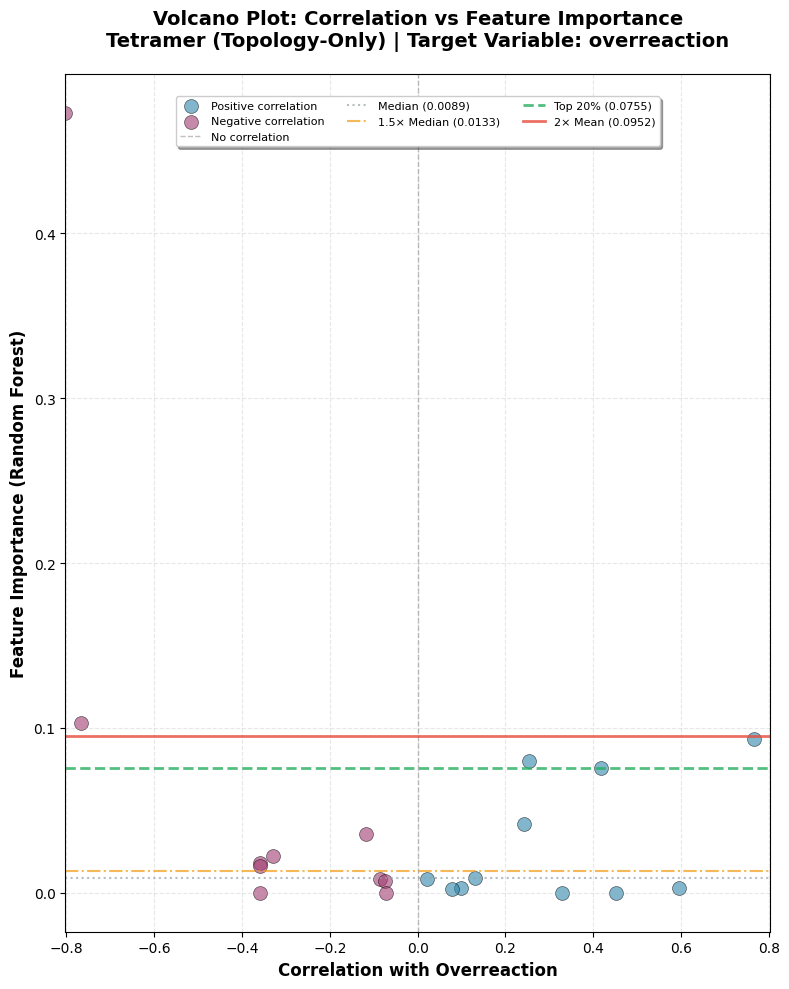


VISUALIZATION SUMMARY
Total features plotted: 21
Positive correlations: 11
Negative correlations: 10

Importance range: [0.0000, 0.4732]
Correlation range: [-0.8028, 0.7670]

--------------------------------------------------------------------------------
IMPORTANCE THRESHOLDS & FEATURE COUNTS
--------------------------------------------------------------------------------
Median importance:           0.0089  →  11 features above
1.5× Median:                 0.0133  →  10 features above
Top 20% (80th percentile):   0.0755  →  5 features above
2× Mean:                     0.0952  →  2 features above

--------------------------------------------------------------------------------
RECOMMENDATION: Use 1.5× Median (0.0133) as a balanced threshold
This identifies 10 important features while avoiding noise.


HIGH IMPORTANCE FEATURES (Above 2× Mean Threshold: 0.0952)


,feature,importance,correlation,sheet,original_value,multimer_ids,matching_columns
0,2,0.473157,-0.802770,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_1, Ub4_2, Ub4_3, Ub4_4]","[trimer_deprotection, trimer_formation]"
1,1,0.103169,-0.766999,Sheet1,"{'protein': '1ubq', 'chain_number': 1, 'FASTA_sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSD...","[Ub4_1, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_deprotection, dimer_formation]"


In [52]:
# Volcano plot: Correlation vs Feature Importance

import matplotlib.pyplot as plt
import numpy as np

if 'agg_df_with_values_and_ids' not in globals() or agg_df_with_values_and_ids is None:
    print("ERROR: agg_df_with_values_and_ids not available. Run the enrichment cell first.")
else:
    df_viz = agg_df_with_values_and_ids.copy()
    
    # Remove rows with NaN correlation
    df_viz = df_viz.dropna(subset=['correlation', 'importance'])
    
    if df_viz.empty:
        print("No data available for visualization.")
    else:
        # Create figure with narrower width
        fig, ax = plt.subplots(figsize=(8, 10))
        
        # Split into positive and negative correlation for coloring
        positive_mask = df_viz['correlation'] > 0
        negative_mask = df_viz['correlation'] < 0
        
        # Plot positive correlations in blue (right side)
        if positive_mask.any():
            ax.scatter(df_viz.loc[positive_mask, 'correlation'], 
                      df_viz.loc[positive_mask, 'importance'],
                      c='#2E86AB', alpha=0.6, s=100, label='Positive correlation', edgecolors='black', linewidth=0.5)
        
        # Plot negative correlations in red (left side)
        if negative_mask.any():
            ax.scatter(df_viz.loc[negative_mask, 'correlation'], 
                      df_viz.loc[negative_mask, 'importance'],
                      c='#A23B72', alpha=0.6, s=100, label='Negative correlation', edgecolors='black', linewidth=0.5)
        
        # Calculate importance thresholds
        median_imp = df_viz['importance'].median()
        mean_imp = df_viz['importance'].mean()
        top_20_pct = df_viz['importance'].quantile(0.80)  # 80th percentile = top 20%
        two_x_mean = 2 * mean_imp
        one_half_x_median = 1.5 * median_imp
        
        # Add vertical reference line (zero correlation)
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No correlation')
        
        # Add horizontal threshold lines (importance thresholds)
        ax.axhline(y=median_imp, color='#95A3A4', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Median ({median_imp:.4f})')
        ax.axhline(y=one_half_x_median, color='#F39C12', linestyle='-.', linewidth=1.5, alpha=0.7, label=f'1.5× Median ({one_half_x_median:.4f})')
        ax.axhline(y=top_20_pct, color='#27AE60', linestyle='--', linewidth=2, alpha=0.8, label=f'Top 20% ({top_20_pct:.4f})')
        ax.axhline(y=two_x_mean, color='#E74C3C', linestyle='-', linewidth=2, alpha=0.8, label=f'2× Mean ({two_x_mean:.4f})')
        
        # Labels and title
        ax.set_xlabel(f'Correlation with {TARGET_VARIABLE.title()}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
        ax.set_title(f'Volcano Plot: Correlation vs Feature Importance\n{analysis_label} | Target Variable: {TARGET_VARIABLE}', 
                    fontsize=14, fontweight='bold', pad=20)
        
        # Legend (place at upper center)
        ax.legend(loc='upper center', frameon=True, shadow=True, fontsize=8, ncol=3, bbox_to_anchor=(0.5, 0.98))
        
        # Set x-axis limits: default to [-0.6, 0.6] but expand if data exceeds this range
        max_abs_corr = max(abs(df_viz['correlation'].min()), abs(df_viz['correlation'].max()))
        x_limit = max(0.6, max_abs_corr)
        ax.set_xlim(-x_limit, x_limit)
        
        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Adjust layout
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics with threshold analysis
        print(f"\n{'='*80}")
        print(f"VISUALIZATION SUMMARY")
        print(f"{'='*80}")
        print(f"Total features plotted: {len(df_viz)}")
        print(f"Positive correlations: {positive_mask.sum()}")
        print(f"Negative correlations: {negative_mask.sum()}")
        print(f"\nImportance range: [{df_viz['importance'].min():.4f}, {df_viz['importance'].max():.4f}]")
        print(f"Correlation range: [{df_viz['correlation'].min():.4f}, {df_viz['correlation'].max():.4f}]")
        
        print(f"\n{'-'*80}")
        print(f"IMPORTANCE THRESHOLDS & FEATURE COUNTS")
        print(f"{'-'*80}")
        print(f"Median importance:           {median_imp:.4f}  →  {(df_viz['importance'] >= median_imp).sum()} features above")
        print(f"1.5× Median:                 {one_half_x_median:.4f}  →  {(df_viz['importance'] >= one_half_x_median).sum()} features above")
        print(f"Top 20% (80th percentile):   {top_20_pct:.4f}  →  {(df_viz['importance'] >= top_20_pct).sum()} features above")
        print(f"2× Mean:                     {two_x_mean:.4f}  →  {(df_viz['importance'] >= two_x_mean).sum()} features above")
        
        print(f"\n{'-'*80}")
        print(f"RECOMMENDATION: Use 1.5× Median ({one_half_x_median:.4f}) as a balanced threshold")
        print(f"This identifies {(df_viz['importance'] >= one_half_x_median).sum()} important features while avoiding noise.")
        print(f"{'='*80}\n")
        
        # Display features above 2× Mean threshold with annotations
        high_importance_features = df_viz[df_viz['importance'] >= two_x_mean].copy()
        if not high_importance_features.empty:
            print(f"\n{'='*80}")
            print(f"HIGH IMPORTANCE FEATURES (Above 2× Mean Threshold: {two_x_mean:.4f})")
            print(f"{'='*80}")
            high_importance_features = high_importance_features.sort_values('importance', ascending=False)
            
            # Add labels to the plot for these features (swapped x and y for volcano plot)
            for idx, row in high_importance_features.iterrows():
                ax.annotate(f"  {row['feature']}", 
                           xy=(row['correlation'], row['importance']),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.8,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='none'))
            
            # Redraw the figure to show annotations
            fig.canvas.draw()
            
            # Display table
            display_cols = ['feature', 'importance', 'correlation', 'sheet', 'original_value', 'multimer_ids', 'matching_columns']
            with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
                display(high_importance_features[display_cols])
            print(f"{'='*80}\n")
        else:
            print(f"\nNo features exceed the 2× Mean threshold ({two_x_mean:.4f})")
            print(f"{'='*80}\n")

# Pipeline Function Wrapper

The function below wraps the entire analysis pipeline (configuration → cleaning → encoding → merging → Random Forest → interpretation → visualization) into a single callable function. This allows you to:

- Run the complete pipeline with different configurations quickly
- Compare results across multiple parameter combinations
- Automate batch analyses

The original detailed cells above remain unchanged and informative for exploratory analysis.

In [ ]:
def run_ubiquitin_ml_pipeline(multimer_size, analysis_mode, target_variable, verbose=True):
    """
    Run the complete ubiquitin machine learning analysis pipeline.
    
    Parameters:
    -----------
    multimer_size : int
        4 for tetramers or 5 for pentamers
    analysis_mode : str
        'protecting_groups', 'topology_only', 'enzymes', or 'donors'
    target_variable : str
        'yield' or 'overreaction'
    verbose : bool
        If True, print detailed progress. If False, suppress most output.
    
    Returns:
    --------
    dict : Results dictionary containing:
        - 'config': Configuration parameters
        - 'rf_results': Random Forest results per sheet
        - 'feature_table': Full enriched feature importance table
        - 'top_positive': Top 10 features that increase target
        - 'top_negative': Top 10 features that decrease target
        - 'high_importance': Features above 2× mean importance threshold
    """
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score, mean_squared_error
    import matplotlib.pyplot as plt
    import sys
    sys.path.insert(0, str(REPO_ROOT / "back_end" / "src"))
    from main import iterate_through_ubiquitin
    from nomenclature import format_nomenclature_preorder_A63B
    
    if verbose:
        print(f"{'='*80}")
        print(f"STARTING PIPELINE")
        print(f"{'='*80}")
    
    # ========== STEP 1: Configuration ==========
    if verbose:
        print(f"\n[1/8] Configuration...")
    
    if multimer_size == 4:
        bandstrength_data = tetramer_bandstrength if 'tetramer_bandstrength' in globals() else None
        if analysis_mode == 'topology_only':
            ubq_data = ms4_ubq_topology_only if 'ms4_ubq_topology_only' in globals() else None
            analysis_label = "Tetramer (Topology-Only)"
        elif analysis_mode == 'protecting_groups':
            ubq_data = ms4_ubq if 'ms4_ubq' in globals() else None
            analysis_label = "Tetramer (With Protecting Groups)"
        elif analysis_mode == 'enzymes':
            ubq_data = ms4_reaction if 'ms4_reaction' in globals() else None
            analysis_label = "Tetramer (Enzymes)"
        elif analysis_mode == 'donors':
            ubq_data = ms4_donor if 'ms4_donor' in globals() else None
            analysis_label = "Tetramer (Donors)"
        else:
            raise ValueError(f"Invalid analysis_mode='{analysis_mode}'")
    elif multimer_size == 5:
        bandstrength_data = pentamer_bandstrength if 'pentamer_bandstrength' in globals() else None
        if analysis_mode == 'topology_only':
            ubq_data = ms5_ubq_topology_only if 'ms5_ubq_topology_only' in globals() else None
            analysis_label = "Pentamer (Topology-Only)"
        elif analysis_mode == 'protecting_groups':
            ubq_data = ms5_ubq if 'ms5_ubq' in globals() else None
            analysis_label = "Pentamer (With Protecting Groups)"
        elif analysis_mode == 'enzymes':
            ubq_data = ms5_reaction if 'ms5_reaction' in globals() else None
            analysis_label = "Pentamer (Enzymes)"
        elif analysis_mode == 'donors':
            ubq_data = ms5_donor if 'ms5_donor' in globals() else None
            analysis_label = "Pentamer (Donors)"
        else:
            raise ValueError(f"Invalid analysis_mode='{analysis_mode}'")
    else:
        raise ValueError(f"Invalid multimer_size={multimer_size}. Must be 4 or 5.")
    
    if ubq_data is not None and 'used_in_synthesis' in ubq_data.columns:
        ubq_data = ubq_data[ubq_data['used_in_synthesis'] == 1].copy()
    
    if verbose:
        print(f"   Config: {analysis_label}, target={target_variable}, shape={ubq_data.shape if ubq_data is not None else 'N/A'}")
    
    # ========== STEP 2: Clean Data ==========
    if verbose:
        print(f"\n[2/8] Cleaning data...")
    
    if ubq_data is None:
        raise ValueError("ubq_data not available for this configuration")
    
    clean_ubq = ubq_data.copy()
    cols_to_drop = [c for c in ['Unnamed: 0', 'Unnamed:0', 'index', 'used_in_synthesis', 'initial_acceptor'] if c in clean_ubq.columns]
    if cols_to_drop:
        clean_ubq = clean_ubq.drop(columns=cols_to_drop)
    
    for col in clean_ubq.columns:
        clean_ubq[col] = clean_ubq[col].astype(str)
    
    if verbose:
        print(f"   Cleaned: {clean_ubq.shape}")
    
    # ========== STEP 3: Collect Unique Values ==========
    if verbose:
        print(f"\n[3/8] Collecting unique values...")
    
    exclude_col = 'multimer_id' if 'multimer_id' in clean_ubq.columns else None
    cols_to_scan = [c for c in clean_ubq.columns if c != exclude_col]
    
    unique_vals = set()
    for c in cols_to_scan:
        try:
            vals = clean_ubq[c].dropna().unique().tolist()
        except Exception:
            vals = []
        for v in vals:
            unique_vals.add(v)
    
    ubq_values_list = sorted(list(unique_vals))
    if verbose:
        print(f"   Found {len(ubq_values_list)} unique values")
    
    # ========== STEP 4: Encode Features ==========
    if verbose:
        print(f"\n[4/8] Encoding features...")
    
    value_to_code = {val: idx for idx, val in enumerate(ubq_values_list, start=1)}
    encoded_df = clean_ubq.copy()
    
    cols_to_encode = [c for c in encoded_df.columns if c != exclude_col]
    for c in cols_to_encode:
        encoded_df[c] = encoded_df[c].map(value_to_code)
    
    if verbose:
        print(f"   Encoded {len(value_to_code)} features")
    
    # ========== STEP 5: Create Feature Counts ==========
    if verbose:
        print(f"\n[5/8] Creating feature count matrix...")
    
    cols_to_scan_enc = [c for c in encoded_df.columns if c != exclude_col]
    unique_codes = set()
    for c in cols_to_scan_enc:
        vals = pd.to_numeric(encoded_df[c], errors='coerce')
        unique_codes.update([v for v in vals.dropna().unique().tolist()])
    unique_codes = sorted(int(v) for v in unique_codes)
    
    out_df = pd.DataFrame()
    if exclude_col:
        out_df[exclude_col] = encoded_df[exclude_col]
    
    for code in unique_codes:
        out_df[str(code)] = (encoded_df[cols_to_scan_enc] == code).sum(axis=1)
    
    value_counts_df = out_df
    if verbose:
        print(f"   Created count matrix: {value_counts_df.shape}")
    
    # ========== STEP 6: Merge with Bandstrength ==========
    if verbose:
        print(f"\n[6/8] Merging with band intensity data...")
    
    if bandstrength_data is None:
        raise ValueError("bandstrength_data not available")
    
    merged_sheets = {}
    counts_df = value_counts_df.copy()
    counts_df['multimer_id'] = counts_df['multimer_id'].astype(str)
    
    for sname, df in bandstrength_data.items():
        df = df.copy()
        if 'multimer_id' in df.columns:
            df['multimer_id'] = df['multimer_id'].astype(str).str.replace('-', '_', regex=False)
            merged = df.merge(counts_df, on='multimer_id', how='left', suffixes=('', '_ubqcounts'))
            merged_sheets[sname] = merged
    
    bandstrength_merged = merged_sheets
    if verbose:
        print(f"   Merged {len(bandstrength_merged)} sheets")
    
    # ========== STEP 7: Train Random Forest ==========
    if verbose:
        print(f"\n[7/8] Training Random Forest models...")
    
    feature_cols = [c for c in value_counts_df.columns if c != 'multimer_id']
    results = {}
    
    for sname, df in bandstrength_merged.items():
        cur = df.copy()
        if target_variable not in cur.columns:
            continue
        
        use_cols = [c for c in feature_cols if c in cur.columns]
        cur = cur.dropna(subset=[target_variable])
        if cur.empty:
            continue
        
        X = cur[use_cols].fillna(0)
        y = pd.to_numeric(cur[target_variable], errors='coerce')
        valid_mask = ~y.isna()
        X = X.loc[valid_mask]
        y = y.loc[valid_mask]
        
        if len(X) < 10:
            rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
            rf.fit(X, y)
            importances = rf.feature_importances_
            fi = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)
            results[sname] = {'model': rf, 'feature_importances': fi, 'train_size': len(X), 'r2_train': rf.score(X, y)}
        else:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
            rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)
            y_pred = rf.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            importances = rf.feature_importances_
            fi = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)
            results[sname] = {'model': rf, 'feature_importances': fi, 'train_size': len(X_train), 'test_size': len(X_test), 'r2_test': r2, 'mse_test': mse}
    
    if verbose:
        print(f"   Trained models for {len(results)} sheets")
    
    # Aggregate features
    agg = []
    for sname, res in results.items():
        fi = res['feature_importances'].copy()
        fi['sheet'] = sname
        agg.append(fi)
    agg_df = pd.concat(agg, ignore_index=True) if agg else pd.DataFrame()
    
    # ========== STEP 8: Enrich with Metadata ==========
    if verbose:
        print(f"\n[8/8] Enriching features with original values and correlations...")
    
    # Map codes back to values
    code_to_value = {int(code): value for value, code in value_to_code.items()}
    feature_json_map = {str(k): code_to_value[k] for k in sorted(code_to_value.keys())}
    
    enriched = agg_df.copy()
    enriched['feature'] = enriched['feature'].astype(str)
    enriched['original_value'] = enriched['feature'].map(feature_json_map)
    
    # Find multimer IDs and matching columns
    def find_ids_for_value(val):
        if pd.isna(val):
            return []
        ids = set()
        search_cols = [c for c in clean_ubq.columns if c != 'multimer_id']
        for c in search_cols:
            mask = clean_ubq[c] == val
            ids.update(clean_ubq.loc[mask, 'multimer_id'].astype(str).tolist())
        return sorted(ids)
    
    def find_columns_for_value(val):
        if pd.isna(val):
            return []
        cols = []
        search_cols = [c for c in clean_ubq.columns if c != 'multimer_id']
        for c in search_cols:
            if (clean_ubq[c] == val).any():
                cols.append(c)
        return sorted(cols)
    
    enriched['multimer_ids'] = enriched['original_value'].apply(find_ids_for_value)
    enriched['matching_columns'] = enriched['original_value'].apply(find_columns_for_value)
    # Alias for display: parent synthetic pathways
    enriched['parent synthetic pathways'] = enriched['multimer_ids']
    
    # Extract lysine information for protecting_groups and topology_only modes
    if analysis_mode in ['protecting_groups', 'topology_only', 'donors']:
        def extract_lysine_info(val):
            if pd.isna(val):
                return [], [], []
            try:
                _, context = iterate_through_ubiquitin(val)
                return (
                    context.get('conjugated_lysines', []),
                    context.get('SMAC_lysines', []),
                    context.get('ABOC_lysines', [])
                )
            except Exception:
                return [], [], []
        
        lysine_data = enriched['original_value'].apply(extract_lysine_info)
        enriched['conjugated_lysines'] = lysine_data.apply(lambda x: x[0])
        enriched['SMAC_lysines'] = lysine_data.apply(lambda x: x[1])
        enriched['ABOC_lysines'] = lysine_data.apply(lambda x: x[2])
        
        # Create UB_ID from conjugated_lysines
        def create_ub_id(conjugated_lysines):
            if not conjugated_lysines or len(conjugated_lysines) == 0:
                return ""
            try:
                return format_nomenclature_preorder_A63B(conjugated_lysines)
            except Exception:
                return ""
        
        enriched['UB_ID'] = enriched['conjugated_lysines'].apply(create_ub_id)
        # Aliases for display tables
        enriched['feature UB_ID'] = enriched['UB_ID']
    else:
        enriched['conjugated_lysines'] = [[] for _ in range(len(enriched))]
        enriched['SMAC_lysines'] = [[] for _ in range(len(enriched))]
        enriched['ABOC_lysines'] = [[] for _ in range(len(enriched))]
        enriched['UB_ID'] = ["" for _ in range(len(enriched))]
        enriched['feature UB_ID'] = ["" for _ in range(len(enriched))]
    
    # Compute correlations
    def compute_feature_correlation(row):
        if pd.isna(row['feature']) or pd.isna(row['sheet']):
            return np.nan
        try:
            feature_col = str(row['feature'])
            sheet_name = row['sheet']
            if sheet_name in bandstrength_merged:
                merged_df = bandstrength_merged[sheet_name]
                if feature_col in merged_df.columns and target_variable in merged_df.columns:
                    return merged_df[feature_col].corr(merged_df[target_variable])
        except Exception:
            pass
        return np.nan
    
    enriched['correlation'] = enriched.apply(compute_feature_correlation, axis=1)
    
    # Split by correlation direction
    positive_corr = enriched[enriched['correlation'] > 0].copy()
    negative_corr = enriched[enriched['correlation'] < 0].copy()
    top_positive = positive_corr.sort_values('importance', ascending=False).head(10)
    top_negative = negative_corr.sort_values('importance', ascending=False).head(10)
    
    # Top 10 Top 10 Top 10 High importance features (above 2× mean)
    mean_imp = enriched['importance'].mean()
    two_x_mean = 2 * mean_imp
    high_importance = enriched[enriched['importance'] >= two_x_mean].sort_values('importance', ascending=False)
    
    if verbose:
        print(f"   Enriched {len(enriched)} features")
        print(f"   Top positive: {len(top_positive)}, Top negative: {len(top_negative)}")
        print(f"   High importance (>2× mean): {len(high_importance)}")
    
    # ========== STEP 9: Generate Volcano Plot ==========
    if verbose:
        print(f"\n[9/9] Generating volcano plot...")
    
    df_viz = enriched.dropna(subset=['correlation', 'importance'])
    
    if not df_viz.empty:
        fig, ax = plt.subplots(figsize=(8, 10))
        
        # Split into positive and negative correlation for coloring
        positive_mask = df_viz['correlation'] > 0
        negative_mask = df_viz['correlation'] < 0
        
        # Plot positive correlations in blue (right side)
        if positive_mask.any():
            ax.scatter(df_viz.loc[positive_mask, 'correlation'], 
                      df_viz.loc[positive_mask, 'importance'],
                      c='#2E86AB', alpha=0.6, s=100, label='Positive correlation', edgecolors='black', linewidth=0.5)
        
        # Plot negative correlations in red (left side)
        if negative_mask.any():
            ax.scatter(df_viz.loc[negative_mask, 'correlation'], 
                      df_viz.loc[negative_mask, 'importance'],
                      c='#A23B72', alpha=0.6, s=100, label='Negative correlation', edgecolors='black', linewidth=0.5)
        
        # Calculate importance thresholds
        median_imp = df_viz['importance'].median()
        one_half_x_median = 1.5 * median_imp
        top_20_pct = df_viz['importance'].quantile(0.80)
        
        # Add vertical reference line (zero correlation)
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No correlation')
        
        # Add horizontal threshold lines (importance thresholds)
        ax.axhline(y=median_imp, color='#95A3A4', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Median ({median_imp:.4f})')
        ax.axhline(y=one_half_x_median, color='#F39C12', linestyle='-.', linewidth=1.5, alpha=0.7, label=f'1.5× Median ({one_half_x_median:.4f})')
        ax.axhline(y=top_20_pct, color='#27AE60', linestyle='--', linewidth=2, alpha=0.8, label=f'Top 20% ({top_20_pct:.4f})')
        ax.axhline(y=two_x_mean, color='#E74C3C', linestyle='-', linewidth=2, alpha=0.8, label=f'2× Mean ({two_x_mean:.4f})')
        
        # Labels and title
        ax.set_xlabel(f'Correlation with {target_variable.title()}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
        ax.set_title(f'Volcano Plot: Correlation vs Feature Importance\n{analysis_label} | Target Variable: {target_variable}', 
                    fontsize=14, fontweight='bold', pad=20)
        
        # Legend (narrow and stacked vertically in center)
        ax.legend(loc='upper center', frameon=True, shadow=True, fontsize=8, ncol=1, bbox_to_anchor=(0.5, 0.98))
        
        # Set x-axis limits: default to [-0.6, 0.6] but expand if data exceeds this range
        max_abs_corr = max(abs(df_viz['correlation'].min()), abs(df_viz['correlation'].max()))
        #x_limit = max(0.6, max_abs_corr)
        #ax.set_xlim(-x_limit, x_limit)
        ax.set_xlim(-1, 1)
        
        # Ensure y-axis ends at 1.0
        ax.set_ylim(-0.1, 1.0)
        
        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add labels to high importance features (above 2× mean)
        if not high_importance.empty:
            for idx, row in high_importance.iterrows():
                if not pd.isna(row['correlation']) and not pd.isna(row['importance']):
                    ax.annotate(f"  {row['feature']}", 
                               xy=(row['correlation'], row['importance']),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.8,
                               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='none'))
        
        # Adjust layout
        plt.tight_layout()
        
        # Save volcano plot and high importance table to PDF
        from matplotlib.backends.backend_pdf import PdfPages
        import os
        
        # Create output directory if it doesn't exist
        output_dir = Path("/Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots")
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Create filename with configuration details
        filename = f"volcano_plot_ms{multimer_size}_{analysis_mode}_{target_variable}.pdf"
        output_path = output_dir / filename
        
        with PdfPages(output_path) as pdf:
            # Save the volcano plot
            pdf.savefig(fig, bbox_inches='tight')

            high_importance = high_importance.head(10)  # Limit to top 50 for table display
            
            # Create a new figure for the high importance features table
            if not high_importance.empty:
                # Calculate figure height based on number of rows
                if analysis_mode in ['protecting_groups', 'topology_only']:
                    num_rows = len(high_importance) + 1  # +1 for header
                    row_height = 1  # Height per row in inches
                    fig_height = max(3, num_rows * row_height)  # Minimum 3 inches, scales with rows
                elif (analysis_mode in ['donors']) & (multimer_size==5):
                    num_rows = len(high_importance) + 1  # +1 for header
                    row_height = 7  # Height per row in inches
                    fig_height = max(3, num_rows * row_height)  # Minimum 3 inches, scales with rows
                else:
                    num_rows = len(high_importance) + 1  # +1 for header
                    row_height = 3  # Height per row in inches
                    fig_height = max(3, num_rows * row_height)  # Minimum 3 inches, scales with rows
                
                fig_table, ax_table = plt.subplots(figsize=(11, fig_height))
                ax_table.axis('tight')
                ax_table.axis('off')
                
                # Prepare table data - select display columns based on analysis mode
                base_cols = ['feature', 'importance', 'correlation', 'original_value', 'parent synthetic pathways']
                if analysis_mode in ['protecting_groups']:
                    table_cols = ['feature', 'importance', 'correlation', 'feature UB_ID', 'SMAC_lysines', 'ABOC_lysines', 'parent synthetic pathways']
                elif analysis_mode in ['topology_only']:
                    table_cols = ['feature', 'importance', 'correlation', 'feature UB_ID', 'parent synthetic pathways']
                elif analysis_mode in ['donors']:
                    table_cols = ['feature', 'importance', 'correlation', 'SMAC_lysines', 'ABOC_lysines', 'parent synthetic pathways']
                else:
                    table_cols = base_cols
                
                # Filter available columns
                available_cols = [col for col in table_cols if col in high_importance.columns]
                table_data = high_importance[available_cols].copy()
                
                # Format numeric columns
                if 'importance' in table_data.columns:
                    table_data['importance'] = table_data['importance'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '')
                if 'correlation' in table_data.columns:
                    table_data['correlation'] = table_data['correlation'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '')
                
                # Convert list columns to strings with special formatting for lysine columns
                for col in table_data.columns:
                    if table_data[col].apply(lambda x: isinstance(x, list)).any():
                        if col in ['SMAC_lysines', 'ABOC_lysines', 'parent synthetic pathways']:
                            # Format lysine columns with line breaks for better wrapping
                            table_data[col] = table_data[col].apply(lambda x: '\n'.join(map(str, x)) if isinstance(x, list) and len(x) > 0 else str(x) if isinstance(x, list) else x)
                        else:
                            table_data[col] = table_data[col].apply(lambda x: str(x) if isinstance(x, list) else x)
                
                # Create table with centered text
                table = ax_table.table(cellText=table_data.values,
                                      colLabels=table_data.columns,
                                      cellLoc='center',
                                      loc='center',
                                      bbox=[0, 0, 1, 1])
                
                table.auto_set_font_size(False)
                table.set_fontsize(7)
                table.scale(1, 1.8)
                
                # Enable proper text wrapping and centering for all cells
                for key, cell in table.get_celld().items():
                    cell.set_text_props(wrap=True, ha='center', va='center', multialignment='center')
                    # Adjust cell properties for better wrapping
                    cell._loc = 'center'
                
                # Style header
                for i in range(len(table_data.columns)):
                    table[(0, i)].set_facecolor('#E74C3C')
                    table[(0, i)].set_text_props(weight='bold', color='white', wrap=True, ha='center', va='center')
                
                ax_table.set_title(f'Top 10 High importance features (>2× Mean)\n{analysis_label} | Target: {target_variable}',
                                  fontsize=12, fontweight='bold', pad=20)
                
                pdf.savefig(fig_table, bbox_inches='tight')
                plt.close(fig_table)
        
        if verbose:
            print(f"   Volcano plot and table saved to: {output_path}")
        
        plt.show()
        
    else:
        if verbose:
            print(f"   No data available for visualization")
    
    # Display results tables
    if verbose:
        # Determine display columns based on analysis mode
        base_cols = ['feature', 'importance', 'correlation', 'original_value', 'parent synthetic pathways', 'matching_columns']
        if analysis_mode in ['protecting_groups']:
            display_cols = ['feature', 'importance', 'correlation', 'feature UB_ID', 'SMAC_lysines', 'ABOC_lysines', 'parent synthetic pathways', 'matching_columns']
        elif analysis_mode in ['topology_only']:
            display_cols = ['feature', 'importance', 'correlation', 'feature UB_ID', 'parent synthetic pathways', 'matching_columns']
        elif analysis_mode in ['donors']:
            display_cols = ['feature', 'importance', 'correlation', 'SMAC_lysines', 'ABOC_lysines', 'parent synthetic pathways', 'matching_columns']
        else:
            display_cols = base_cols
        
        print(f"\n{'='*80}")
        print(f"Top 10 features that INCREASE the target:")
        print(f"{'='*80}")
        display(top_positive[display_cols])
        
        print(f"\n{'='*80}")
        print(f"Top 10 features that DECREASE the target:")
        print(f"{'='*80}")
        display(top_negative[display_cols])
        
        print(f"\n{'='*80}")
        print(f"Top 10 High importance features (above 2× mean):")
        print(f"{'='*80}")
        display(high_importance[display_cols])
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"PIPELINE COMPLETE")
        print(f"{'='*80}\n")
    
    return {
        'config': {
            'multimer_size': multimer_size,
            'analysis_mode': analysis_mode,
            'analysis_label': analysis_label,
            'target_variable': target_variable
        },
        'rf_results': results,
        'feature_table': enriched,
        'top_positive': top_positive,
        'top_negative': top_negative,
        'high_importance': high_importance,
        'thresholds': {
            'mean': mean_imp,
            '2x_mean': two_x_mean,
            'median': enriched['importance'].median(),
            '1.5x_median': 1.5 * enriched['importance'].median(),
            'top_20_pct': enriched['importance'].quantile(0.80)
        }
    }

## Pipeline Usage

Run the pipeline function with different configurations:


Running: Multimer Size 4 | Analysis Mode: topology_with_PG | Target: yield

STARTING PIPELINE

[1/8] Configuration...

✗ Error with multimer_size_5/ubiquitin_history: Invalid analysis_mode='topology_with_PG'

Running: Multimer Size 4 | Analysis Mode: topology_with_PG | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...

✗ Error with multimer_size_5/ubiquitin_history: Invalid analysis_mode='topology_with_PG'

Running: Multimer Size 4 | Analysis Mode: topology_only | Target: yield

STARTING PIPELINE

[1/8] Configuration...
   Config: Tetramer (Topology-Only), target=yield, shape=(14, 11)

[2/8] Cleaning data...
   Cleaned: (14, 7)

[3/8] Collecting unique values...
   Found 21 unique values

[4/8] Encoding features...
   Encoded 21 features

[5/8] Creating feature count matrix...
   Created count matrix: (14, 22)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with

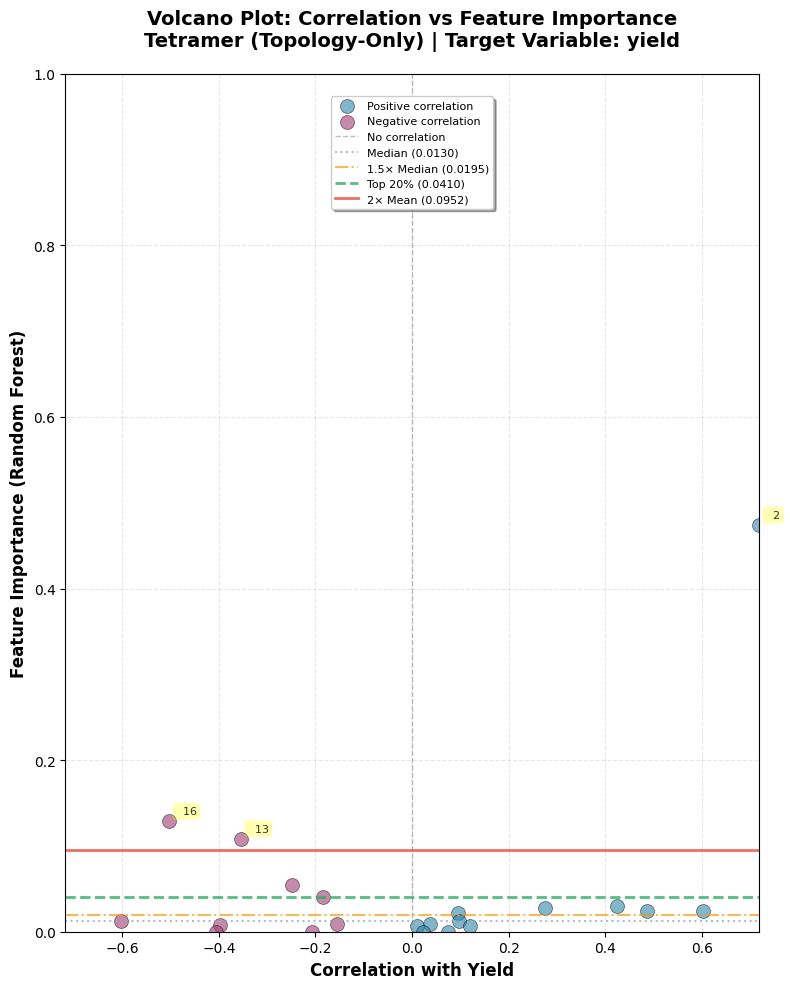


Top 10 features that INCREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,2,0.473949,0.717679,A48B-B48C,"[Ub4_1, Ub4_2, Ub4_3, Ub4_4]","[trimer_deprotection, trimer_formation]"
5,11,0.029891,0.424158,A63B-A48C-C48D,[Ub4_4],"[final_multimer, tetramer_formation]"
6,6,0.028052,0.274043,A48B-B63C-B48D,[Ub4_3],"[final_multimer, tetramer_formation]"
7,4,0.024701,0.485497,A48B-B48C-C63D,[Ub4_2],"[final_multimer, tetramer_formation]"
8,1,0.024623,0.601435,A48B,"[Ub4_1, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_deprotection, dimer_formation]"
9,10,0.021595,0.095879,A63B-A48C,"[Ub4_7, Ub4_8]","[trimer_deprotection, trimer_formation]"
11,21,0.012917,0.097528,A63B-B63C-C63D,[Ub4_14],"[final_multimer, tetramer_formation]"
13,7,0.008696,0.037386,A48B-B63C-C48D,[Ub4_5],"[final_multimer, tetramer_formation]"
15,12,0.006833,0.119529,A63B-A48C-C63D,[Ub4_7],"[final_multimer, tetramer_formation]"
16,14,0.006450,0.010744,A63B-B48C-A48D,[Ub4_8],"[final_multimer, tetramer_formation]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
1,16,0.128772,-0.502887,A63B-B48C-C63D,[Ub4_11],"[final_multimer, tetramer_formation]"
2,13,0.108470,-0.354005,A63B-B48C,"[Ub4_10, Ub4_11]","[trimer_deprotection, trimer_formation]"
3,8,0.054968,-0.248151,A48B-B63C-C63D,[Ub4_6],"[final_multimer, tetramer_formation]"
4,18,0.040985,-0.183595,A63B-B63C-A48D,[Ub4_9],"[final_multimer, tetramer_formation]"
10,9,0.013030,-0.601435,A63B,"[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_8, Ub4_9]","[dimer_deprotection, dimer_formation]"
12,5,0.008810,-0.155119,A48B-B63C,"[Ub4_5, Ub4_6]","[trimer_deprotection, trimer_formation]"
14,17,0.007259,-0.397580,A63B-B63C,"[Ub4_12, Ub4_13, Ub4_14, Ub4_9]","[trimer_deprotection, trimer_formation]"
19,19,0.000000,-0.404952,A63B-B63C-B48D,[Ub4_12],"[final_multimer, tetramer_formation]"
20,20,0.000000,-0.206382,A63B-B63C-C48D,[Ub4_13],"[final_multimer, tetramer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,2,0.473949,0.717679,A48B-B48C,"[Ub4_1, Ub4_2, Ub4_3, Ub4_4]","[trimer_deprotection, trimer_formation]"
1,16,0.128772,-0.502887,A63B-B48C-C63D,[Ub4_11],"[final_multimer, tetramer_formation]"
2,13,0.108470,-0.354005,A63B-B48C,"[Ub4_10, Ub4_11]","[trimer_deprotection, trimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms4_topology_only_yield

Running: Multimer Size 4 | Analysis Mode: topology_only | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...
   Config: Tetramer (Topology-Only), target=overreaction, shape=(14, 11)

[2/8] Cleaning data...
   Cleaned: (14, 7)

[3/8] Collecting unique values...
   Found 21 unique values

[4/8] Encoding features...
   Encoded 21 features

[5/8] Creating feature count matrix...
   Created count matrix: (14, 22)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 21 features
   Top positive: 10, Top negative: 10
   High importance (>2× mean): 2

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms4_topology_only_overreaction.pdf


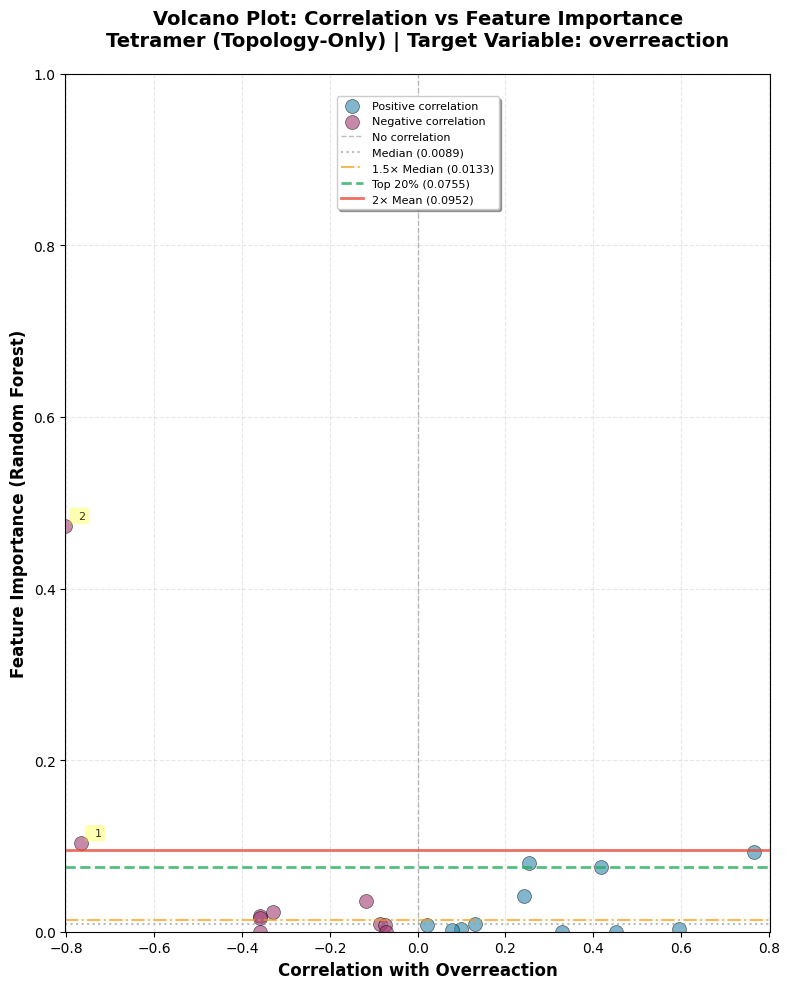


Top 10 features that INCREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
2,9,0.093436,0.766999,A63B,"[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_8, Ub4_9]","[dimer_deprotection, dimer_formation]"
3,13,0.079655,0.254465,A63B-B48C,"[Ub4_10, Ub4_11]","[trimer_deprotection, trimer_formation]"
4,16,0.075452,0.417790,A63B-B48C-C63D,[Ub4_11],"[final_multimer, tetramer_formation]"
5,18,0.041565,0.243231,A63B-B63C-A48D,[Ub4_9],"[final_multimer, tetramer_formation]"
10,10,0.008875,0.129876,A63B-A48C,"[Ub4_7, Ub4_8]","[trimer_deprotection, trimer_formation]"
12,21,0.008384,0.020847,A63B-B63C-C63D,[Ub4_14],"[final_multimer, tetramer_formation]"
14,14,0.003022,0.098207,A63B-B48C-A48D,[Ub4_8],"[final_multimer, tetramer_formation]"
15,17,0.002640,0.595817,A63B-B63C,"[Ub4_12, Ub4_13, Ub4_14, Ub4_9]","[trimer_deprotection, trimer_formation]"
16,12,0.002402,0.078259,A63B-A48C-C63D,[Ub4_7],"[final_multimer, tetramer_formation]"
19,19,0.000000,0.452516,A63B-B63C-B48D,[Ub4_12],"[final_multimer, tetramer_formation]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,2,0.473157,-0.802770,A48B-B48C,"[Ub4_1, Ub4_2, Ub4_3, Ub4_4]","[trimer_deprotection, trimer_formation]"
1,1,0.103169,-0.766999,A48B,"[Ub4_1, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_deprotection, dimer_formation]"
6,5,0.035782,-0.117166,A48B-B63C,"[Ub4_5, Ub4_6]","[trimer_deprotection, trimer_formation]"
7,11,0.022525,-0.330119,A63B-A48C-C48D,[Ub4_4],"[final_multimer, tetramer_formation]"
8,4,0.017947,-0.359344,A48B-B48C-C63D,[Ub4_2],"[final_multimer, tetramer_formation]"
9,6,0.016171,-0.359344,A48B-B63C-B48D,[Ub4_3],"[final_multimer, tetramer_formation]"
11,7,0.008534,-0.085787,A48B-B63C-C48D,[Ub4_5],"[final_multimer, tetramer_formation]"
13,8,0.007282,-0.073411,A48B-B63C-C63D,[Ub4_6],"[final_multimer, tetramer_formation]"
17,15,0.000000,-0.072039,A63B-B48C-C48D,[Ub4_10],"[final_multimer, tetramer_formation]"
18,3,0.000000,-0.359344,A48B-B48C-C48D,[Ub4_1],"[final_multimer, tetramer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,2,0.473157,-0.802770,A48B-B48C,"[Ub4_1, Ub4_2, Ub4_3, Ub4_4]","[trimer_deprotection, trimer_formation]"
1,1,0.103169,-0.766999,A48B,"[Ub4_1, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_deprotection, dimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms4_topology_only_overreaction

Running: Multimer Size 4 | Analysis Mode: enzymes | Target: yield

STARTING PIPELINE

[1/8] Configuration...
   Config: Tetramer (Enzymes), target=yield, shape=(14, 10)

[2/8] Cleaning data...
   Cleaned: (14, 6)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (14, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 3
   High importance (>2× mean): 2

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms4_enzymes_yield.pdf


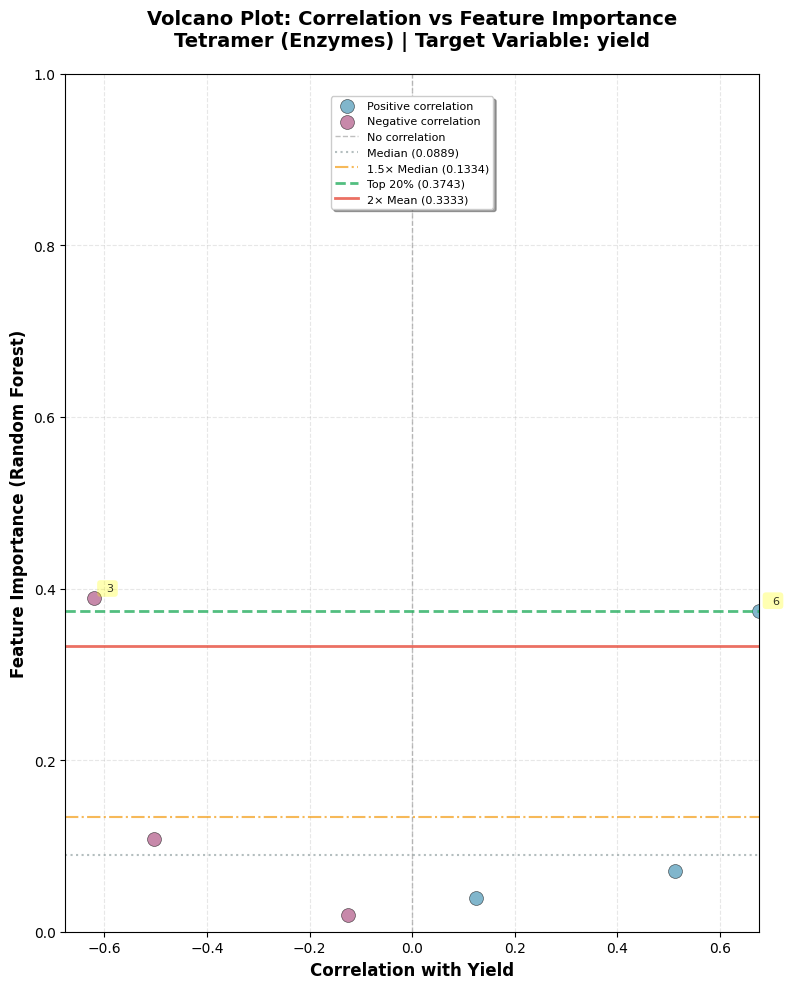


Top 10 features that INCREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
1,6,0.374255,0.676329,gp78/Ube2g2,"[Ub4_1, Ub4_10, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_formation, tetramer_formation, trimer_formation]"
3,4,0.070238,0.513245,Ubc13/Mms2 (branching),"[Ub4_3, Ub4_4, Ub4_7]","[tetramer_formation, trimer_formation]"
4,1,0.039412,0.124862,FAKE_deprot,"[Ub4_12, Ub4_3, Ub4_4, Ub4_7, Ub4_8, Ub4_9]","[dimer_deprotection, trimer_deprotection]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
0,3,0.388470,-0.621251,Ubc13/Mms2,"[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_2, Ub4_5, Ub4_6, Ub4_7, Ub4_8, Ub4_9]","[dimer_formation, tetramer_formation, trimer_formation]"
2,5,0.107650,-0.503356,Ube2K,"[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_5, Ub4_8, Ub4_9]","[tetramer_formation, trimer_formation]"
5,2,0.019976,-0.124862,SMAC_deprot,"[Ub4_1, Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7, Ub4_8, Ub4_9]","[dimer_deprotection, trimer_deprotection]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
0,3,0.388470,-0.621251,Ubc13/Mms2,"[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_2, Ub4_5, Ub4_6, Ub4_7, Ub4_8, Ub4_9]","[dimer_formation, tetramer_formation, trimer_formation]"
1,6,0.374255,0.676329,gp78/Ube2g2,"[Ub4_1, Ub4_10, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_formation, tetramer_formation, trimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms4_enzymes_yield

Running: Multimer Size 4 | Analysis Mode: enzymes | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...
   Config: Tetramer (Enzymes), target=overreaction, shape=(14, 10)

[2/8] Cleaning data...
   Cleaned: (14, 6)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (14, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 3
   High importance (>2× mean): 1

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms4_enzymes_overreaction.pdf


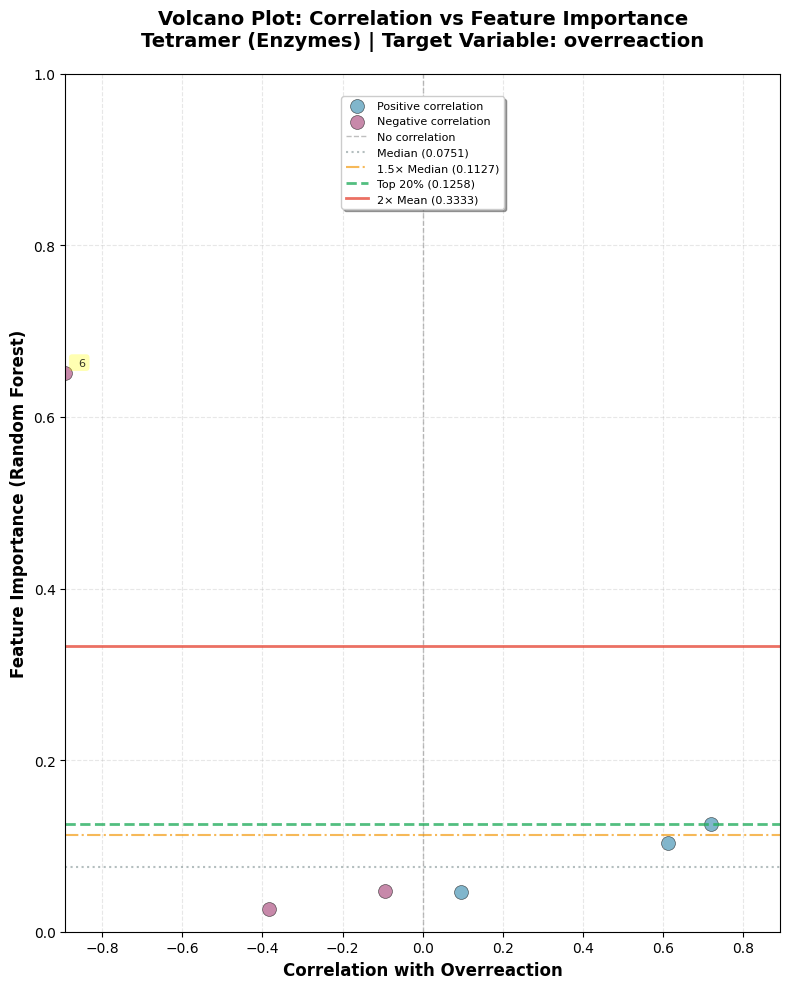


Top 10 features that INCREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
1,3,0.125786,0.719180,Ubc13/Mms2,"[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_2, Ub4_5, Ub4_6, Ub4_7, Ub4_8, Ub4_9]","[dimer_formation, tetramer_formation, trimer_formation]"
2,5,0.103203,0.612380,Ube2K,"[Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_5, Ub4_8, Ub4_9]","[tetramer_formation, trimer_formation]"
4,1,0.046269,0.095107,FAKE_deprot,"[Ub4_12, Ub4_3, Ub4_4, Ub4_7, Ub4_8, Ub4_9]","[dimer_deprotection, trimer_deprotection]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
0,6,0.651754,-0.892067,gp78/Ube2g2,"[Ub4_1, Ub4_10, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_formation, tetramer_formation, trimer_formation]"
3,2,0.047055,-0.095107,SMAC_deprot,"[Ub4_1, Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7, Ub4_8, Ub4_9]","[dimer_deprotection, trimer_deprotection]"
5,4,0.025934,-0.383620,Ubc13/Mms2 (branching),"[Ub4_3, Ub4_4, Ub4_7]","[tetramer_formation, trimer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
0,6,0.651754,-0.892067,gp78/Ube2g2,"[Ub4_1, Ub4_10, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7]","[dimer_formation, tetramer_formation, trimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms4_enzymes_overreaction

Running: Multimer Size 4 | Analysis Mode: donors | Target: yield

STARTING PIPELINE

[1/8] Configuration...
   Config: Tetramer (Donors), target=yield, shape=(14, 10)

[2/8] Cleaning data...
   Cleaned: (14, 6)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (14, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 2
   High importance (>2× mean): 1

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms4_donors_yield.pdf


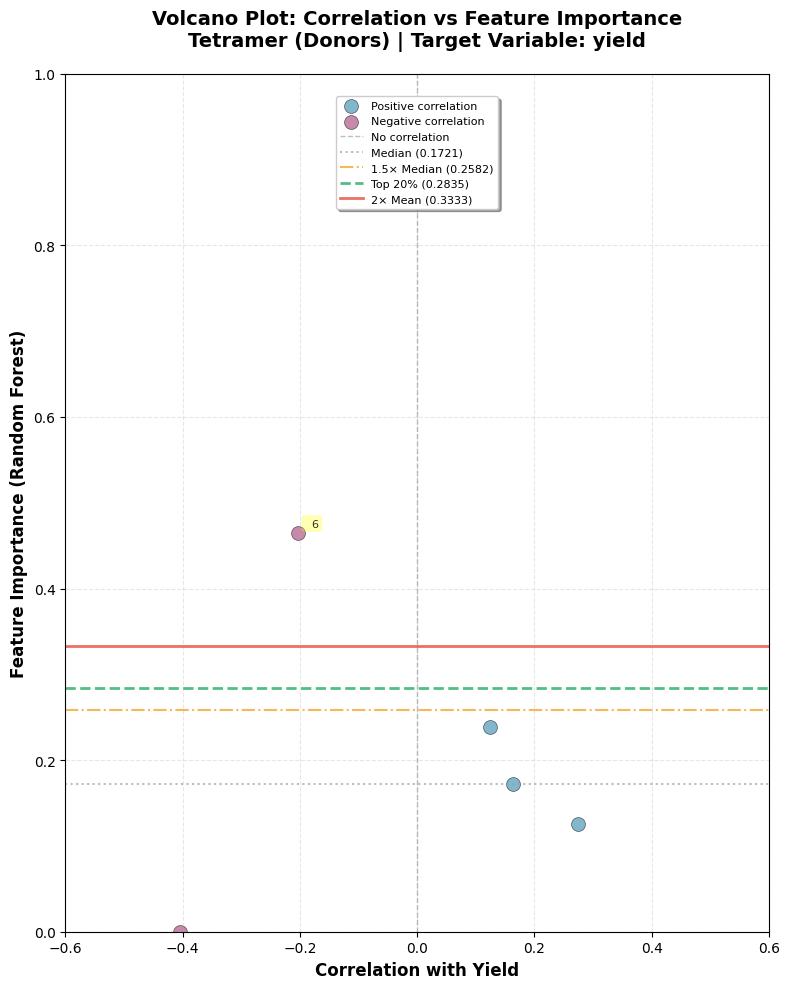


Top 10 features that INCREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
1,3,0.238380,0.124862,[],"[[1, K63], [1, K48]]","[Ub4_1, Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7, Ub4_8, Ub4_9]","[tetramer_formation, trimer_formation]"
2,4,0.172135,0.162902,"[[1, K48]]","[[1, K63]]","[Ub4_1, Ub4_10, Ub4_11, Ub4_13, Ub4_2, Ub4_4, Ub4_5, Ub4_8]","[dimer_formation, trimer_formation]"
3,2,0.125319,0.274043,"[[1, K48]]",[],[Ub4_3],[dimer_formation]



Top 10 features that DECREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,6,0.464166,-0.203019,"[[1, K63]]","[[1, K48]]","[Ub4_11, Ub4_13, Ub4_14, Ub4_2, Ub4_5, Ub4_6, Ub4_7, Ub4_9]","[dimer_formation, trimer_formation]"
5,5,0.000000,-0.404952,"[[1, K63]]",[],[Ub4_12],[dimer_formation]



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,6,0.464166,-0.203019,"[[1, K63]]","[[1, K48]]","[Ub4_11, Ub4_13, Ub4_14, Ub4_2, Ub4_5, Ub4_6, Ub4_7, Ub4_9]","[dimer_formation, trimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms4_donors_yield

Running: Multimer Size 4 | Analysis Mode: donors | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...
   Config: Tetramer (Donors), target=overreaction, shape=(14, 10)

[2/8] Cleaning data...
   Cleaned: (14, 6)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (14, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 2
   High importance (>2× mean): 1

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms4_donors_overreaction.pdf


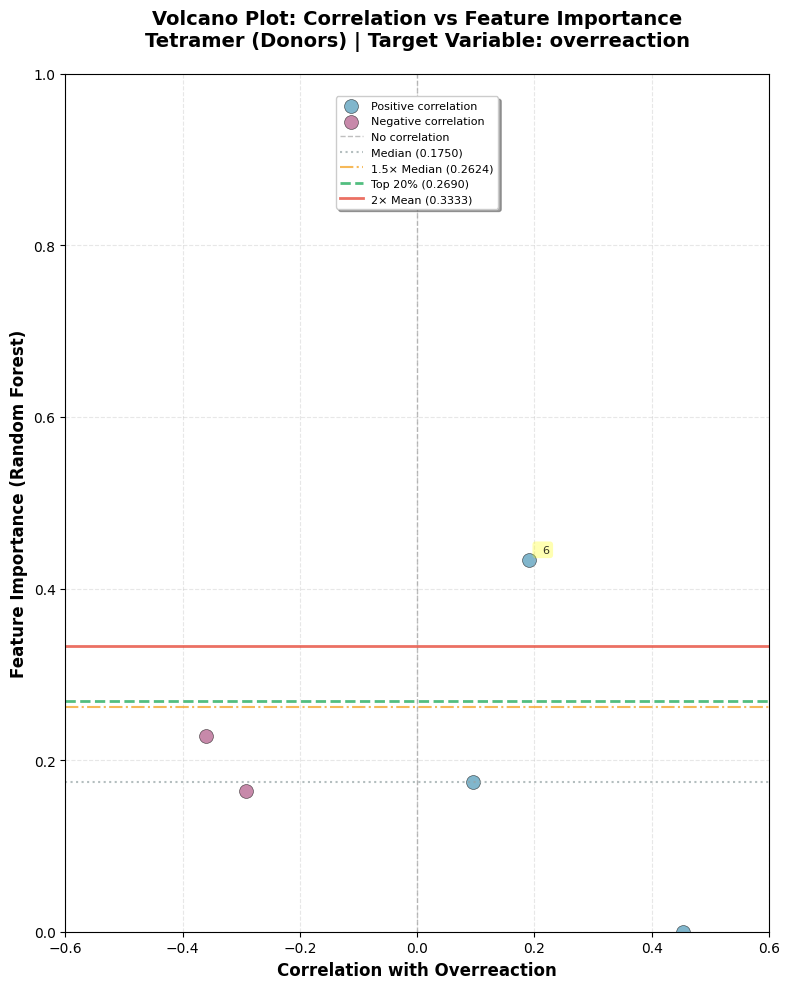


Top 10 features that INCREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,6,0.433563,0.190457,"[[1, K63]]","[[1, K48]]","[Ub4_11, Ub4_13, Ub4_14, Ub4_2, Ub4_5, Ub4_6, Ub4_7, Ub4_9]","[dimer_formation, trimer_formation]"
2,3,0.174962,0.095107,[],"[[1, K63], [1, K48]]","[Ub4_1, Ub4_10, Ub4_11, Ub4_12, Ub4_13, Ub4_14, Ub4_2, Ub4_3, Ub4_4, Ub4_5, Ub4_6, Ub4_7, Ub4_8, Ub4_9]","[tetramer_formation, trimer_formation]"
5,5,0.000000,0.452516,"[[1, K63]]",[],[Ub4_12],[dimer_formation]



Top 10 features that DECREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
1,2,0.227846,-0.359344,"[[1, K48]]",[],[Ub4_3],[dimer_formation]
3,4,0.163628,-0.291994,"[[1, K48]]","[[1, K63]]","[Ub4_1, Ub4_10, Ub4_11, Ub4_13, Ub4_2, Ub4_4, Ub4_5, Ub4_8]","[dimer_formation, trimer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,6,0.433563,0.190457,"[[1, K63]]","[[1, K48]]","[Ub4_11, Ub4_13, Ub4_14, Ub4_2, Ub4_5, Ub4_6, Ub4_7, Ub4_9]","[dimer_formation, trimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms4_donors_overreaction

Running: Multimer Size 5 | Analysis Mode: topology_with_PG | Target: yield

STARTING PIPELINE

[1/8] Configuration...

✗ Error with ms4_donors_overreaction: Invalid analysis_mode='topology_with_PG'

Running: Multimer Size 5 | Analysis Mode: topology_with_PG | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...

✗ Error with ms4_donors_overreaction: Invalid analysis_mode='topology_with_PG'

Running: Multimer Size 5 | Analysis Mode: topology_only | Target: yield

STARTING PIPELINE

[1/8] Configuration...
   Config: Pentamer (Topology-Only), target=yield, shape=(42, 13)

[2/8] Cleaning data...
   Cleaned: (42, 9)

[3/8] Collecting unique values...
   Found 63 unique values

[4/8] Encoding features...
   Encoded 63 features

[5/8] Creating feature count matrix...
   Created count matrix: (42, 64)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1

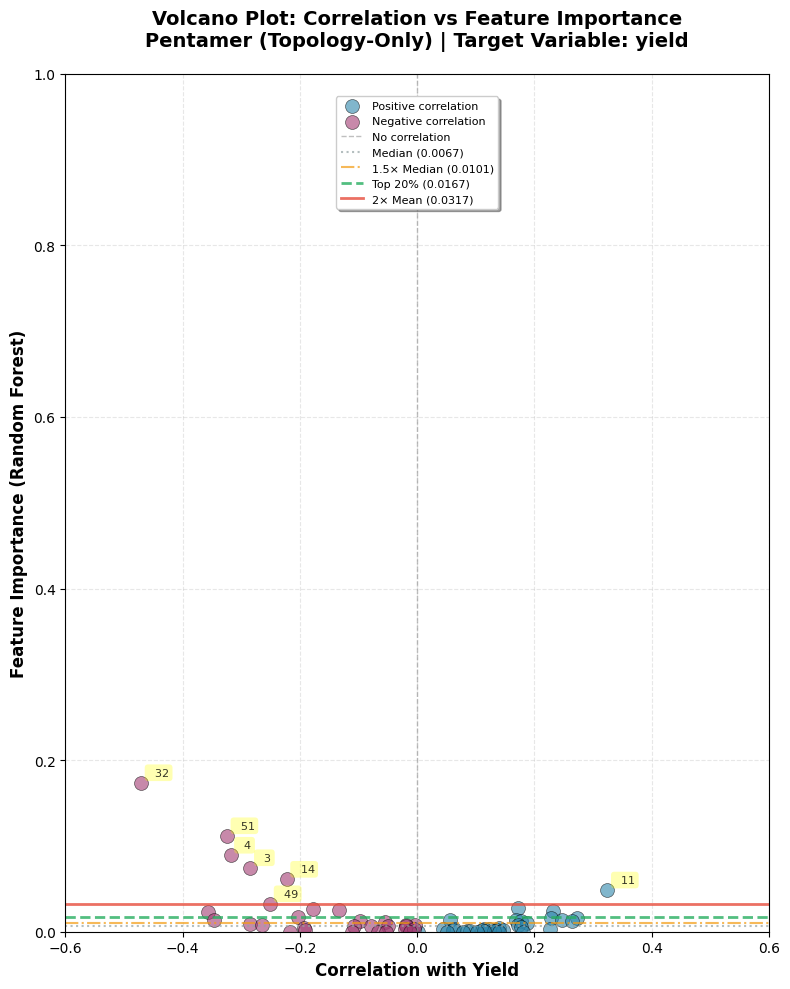


Top 10 features that INCREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
5,11,0.048628,0.324408,A48B-B63C-B48D,"[Ub5_10, Ub5_11, Ub5_8]","[tetramer_deprotection, tetramer_formation]"
7,2,0.027532,0.171822,A48B-B48C,"[Ub5_1, Ub5_10, Ub5_11, Ub5_13, Ub5_2, Ub5_3, Ub5_4, Ub5_5, Ub5_6, Ub5_7, Ub5_8, Ub5_9]","[trimer_deprotection, trimer_formation]"
10,31,0.024495,0.232391,A63B-A48C-C63D-D63E,[Ub5_21],"[final_multimer, pentamer_formation]"
13,24,0.016193,0.228240,A63B-A48C,"[Ub5_12, Ub5_18, Ub5_21, Ub5_22, Ub5_24, Ub5_25, Ub5_26]","[trimer_deprotection, trimer_formation]"
14,19,0.016153,0.271936,A48B-B63C-C63D-B48E,[Ub5_11],"[final_multimer, pentamer_formation]"
15,34,0.013937,0.246269,A63B-B48C-A48D-D48E,[Ub5_13],"[final_multimer, pentamer_formation]"
16,58,0.013584,0.169028,A63B-B63C-C63D,"[Ub5_28, Ub5_37, Ub5_40, Ub5_41, Ub5_42]","[tetramer_deprotection, tetramer_formation]"
17,7,0.013325,0.056516,A48B-B48C-C63D-C48E,[Ub5_3],"[final_multimer, pentamer_formation]"
19,25,0.012576,0.177170,A63B-A48C-C48D,"[Ub5_13, Ub5_9]","[tetramer_deprotection, tetramer_formation]"
21,1,0.012441,0.264854,A48B,"[Ub5_1, Ub5_10, Ub5_11, Ub5_13, Ub5_15, Ub5_16, Ub5_17, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_22, Ub5_26, Ub5_3, Ub5_4,...","[dimer_deprotection, dimer_formation]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,32,0.173705,-0.470693,A63B-B48C,"[Ub5_29, Ub5_30, Ub5_31, Ub5_33, Ub5_34]","[trimer_deprotection, trimer_formation]"
1,51,0.111893,-0.324265,A63B-B63C-B48D-D48E,[Ub5_32],"[final_multimer, pentamer_formation]"
2,4,0.089196,-0.318239,A48B-B48C-C48D-D48E,[Ub5_1],"[final_multimer, pentamer_formation]"
3,3,0.074622,-0.284277,A48B-B48C-C48D,"[Ub5_1, Ub5_2, Ub5_3, Ub5_4, Ub5_5]","[tetramer_deprotection, tetramer_formation]"
4,14,0.061137,-0.222491,A48B-B63C-C48D,"[Ub5_15, Ub5_16]","[tetramer_deprotection, tetramer_formation]"
6,49,0.032590,-0.250660,A63B-B63C-B48D,"[Ub5_32, Ub5_35, Ub5_36]","[tetramer_deprotection, tetramer_formation]"
8,5,0.026531,-0.176997,A48B-B48C-C48D-D63E,[Ub5_2],"[final_multimer, pentamer_formation]"
9,56,0.025356,-0.133607,A63B-B63C-C48D-D48E,[Ub5_38],"[final_multimer, pentamer_formation]"
11,40,0.022697,-0.356076,A63B-B48C-C63D,"[Ub5_31, Ub5_33, Ub5_34]","[tetramer_deprotection, tetramer_formation]"
12,16,0.016970,-0.203296,A48B-B63C-C48D-D48E,[Ub5_15],"[final_multimer, pentamer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,32,0.173705,-0.470693,A63B-B48C,"[Ub5_29, Ub5_30, Ub5_31, Ub5_33, Ub5_34]","[trimer_deprotection, trimer_formation]"
1,51,0.111893,-0.324265,A63B-B63C-B48D-D48E,[Ub5_32],"[final_multimer, pentamer_formation]"
2,4,0.089196,-0.318239,A48B-B48C-C48D-D48E,[Ub5_1],"[final_multimer, pentamer_formation]"
3,3,0.074622,-0.284277,A48B-B48C-C48D,"[Ub5_1, Ub5_2, Ub5_3, Ub5_4, Ub5_5]","[tetramer_deprotection, tetramer_formation]"
4,14,0.061137,-0.222491,A48B-B63C-C48D,"[Ub5_15, Ub5_16]","[tetramer_deprotection, tetramer_formation]"
5,11,0.048628,0.324408,A48B-B63C-B48D,"[Ub5_10, Ub5_11, Ub5_8]","[tetramer_deprotection, tetramer_formation]"
6,49,0.032590,-0.250660,A63B-B63C-B48D,"[Ub5_32, Ub5_35, Ub5_36]","[tetramer_deprotection, tetramer_formation]"



PIPELINE COMPLETE


✓ Completed: ms5_topology_only_yield

Running: Multimer Size 5 | Analysis Mode: topology_only | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...
   Config: Pentamer (Topology-Only), target=overreaction, shape=(42, 13)

[2/8] Cleaning data...
   Cleaned: (42, 9)

[3/8] Collecting unique values...
   Found 63 unique values

[4/8] Encoding features...
   Encoded 63 features

[5/8] Creating feature count matrix...
   Created count matrix: (42, 64)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 63 features
   Top positive: 10, Top negative: 10
   High importance (>2× mean): 5

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms5_topology_only_overreaction.pdf


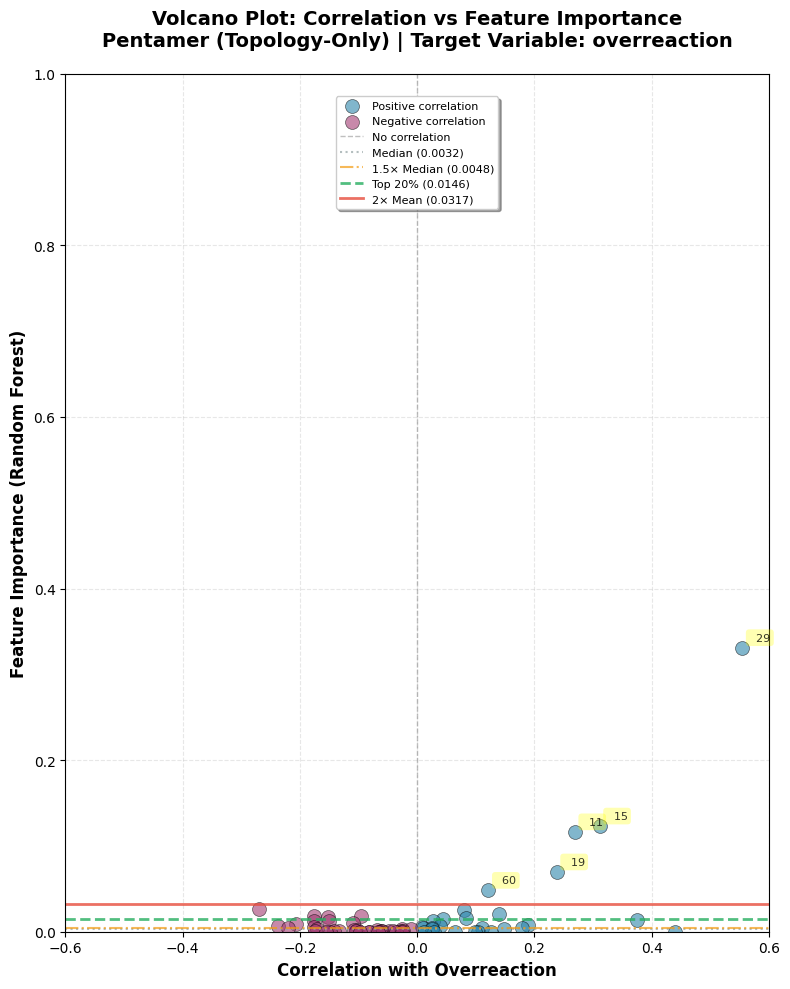


Top 10 features that INCREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,29,0.331125,0.554389,A63B-A48C-C63D-C48E,[Ub5_12],"[final_multimer, pentamer_formation]"
1,15,0.123229,0.311156,A48B-B63C-C48D-B48E,[Ub5_10],"[final_multimer, pentamer_formation]"
2,11,0.116491,0.268819,A48B-B63C-B48D,"[Ub5_10, Ub5_11, Ub5_8]","[tetramer_deprotection, tetramer_formation]"
3,19,0.069716,0.237909,A48B-B63C-C63D-B48E,[Ub5_11],"[final_multimer, pentamer_formation]"
4,60,0.048275,0.121522,A63B-B63C-C63D-B48E,[Ub5_37],"[final_multimer, pentamer_formation]"
6,12,0.025537,0.080234,A48B-B63C-B48D-D48E,[Ub5_4],"[final_multimer, pentamer_formation]"
7,2,0.020446,0.139852,A48B-B48C,"[Ub5_1, Ub5_10, Ub5_11, Ub5_13, Ub5_2, Ub5_3, Ub5_4, Ub5_5, Ub5_6, Ub5_7, Ub5_8, Ub5_9]","[trimer_deprotection, trimer_formation]"
11,34,0.015419,0.083246,A63B-B48C-A48D-D48E,[Ub5_13],"[final_multimer, pentamer_formation]"
12,45,0.014981,0.044395,A63B-B63C,"[Ub5_14, Ub5_23, Ub5_27, Ub5_28, Ub5_32, Ub5_35, Ub5_36, Ub5_37, Ub5_38, Ub5_39, Ub5_40, Ub5_41, Ub5_42]","[trimer_deprotection, trimer_formation]"
13,25,0.013960,0.374264,A63B-A48C-C48D,"[Ub5_13, Ub5_9]","[tetramer_deprotection, tetramer_formation]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
5,32,0.026165,-0.268826,A63B-B48C,"[Ub5_29, Ub5_30, Ub5_31, Ub5_33, Ub5_34]","[trimer_deprotection, trimer_formation]"
8,13,0.018596,-0.094955,A48B-B63C-B48D-D63E,[Ub5_8],"[final_multimer, pentamer_formation]"
9,4,0.017940,-0.175983,A48B-B48C-C48D-D48E,[Ub5_1],"[final_multimer, pentamer_formation]"
10,51,0.017445,-0.151849,A63B-B63C-B48D-D48E,[Ub5_32],"[final_multimer, pentamer_formation]"
15,7,0.012696,-0.175983,A48B-B48C-C63D-C48E,[Ub5_3],"[final_multimer, pentamer_formation]"
16,35,0.011927,-0.151089,A63B-B48C-A48D-D63E,[Ub5_22],"[final_multimer, pentamer_formation]"
17,3,0.010205,-0.109181,A48B-B48C-C48D,"[Ub5_1, Ub5_2, Ub5_3, Ub5_4, Ub5_5]","[tetramer_deprotection, tetramer_formation]"
18,10,0.009408,-0.206797,A48B-B63C,"[Ub5_15, Ub5_16, Ub5_17, Ub5_19, Ub5_20]","[trimer_deprotection, trimer_formation]"
20,6,0.006853,-0.236656,A48B-B48C-C63D,"[Ub5_6, Ub5_7]","[tetramer_deprotection, tetramer_formation]"
23,8,0.005404,-0.175983,A48B-B48C-C63D-D48E,[Ub5_6],"[final_multimer, pentamer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,feature UB_ID,parent synthetic pathways,matching_columns
0,29,0.331125,0.554389,A63B-A48C-C63D-C48E,[Ub5_12],"[final_multimer, pentamer_formation]"
1,15,0.123229,0.311156,A48B-B63C-C48D-B48E,[Ub5_10],"[final_multimer, pentamer_formation]"
2,11,0.116491,0.268819,A48B-B63C-B48D,"[Ub5_10, Ub5_11, Ub5_8]","[tetramer_deprotection, tetramer_formation]"
3,19,0.069716,0.237909,A48B-B63C-C63D-B48E,[Ub5_11],"[final_multimer, pentamer_formation]"
4,60,0.048275,0.121522,A63B-B63C-C63D-B48E,[Ub5_37],"[final_multimer, pentamer_formation]"



PIPELINE COMPLETE


✓ Completed: ms5_topology_only_overreaction

Running: Multimer Size 5 | Analysis Mode: enzymes | Target: yield

STARTING PIPELINE

[1/8] Configuration...
   Config: Pentamer (Enzymes), target=yield, shape=(42, 12)

[2/8] Cleaning data...
   Cleaned: (42, 8)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (42, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 3
   High importance (>2× mean): 0

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms5_enzymes_yield.pdf


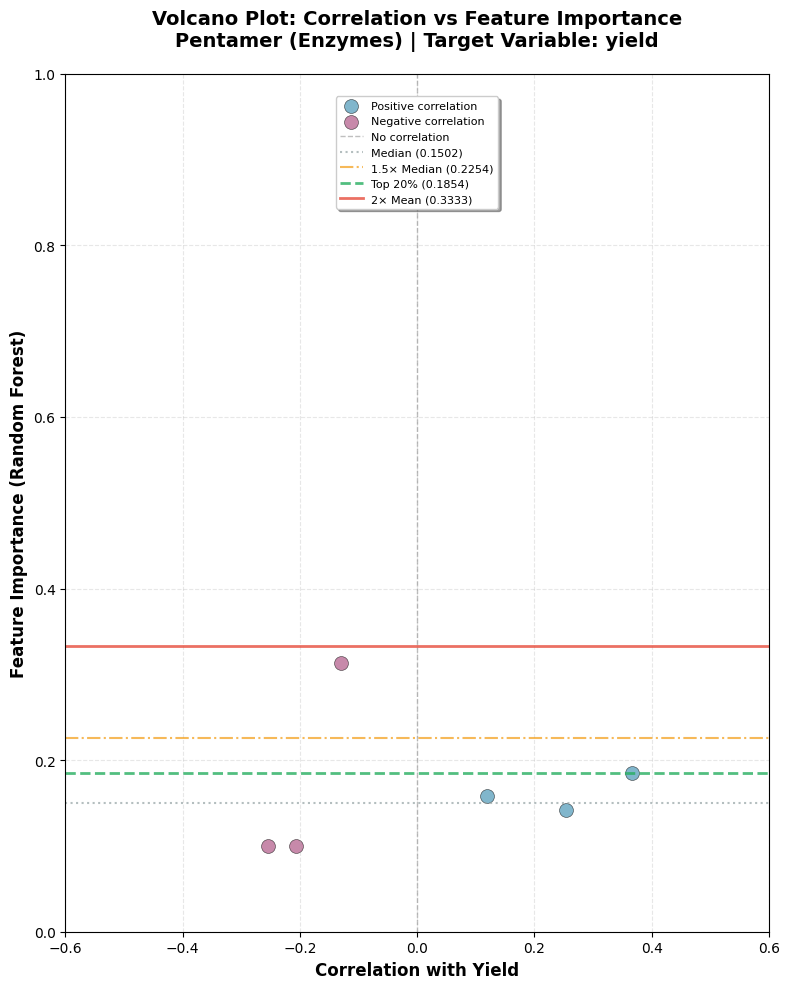


Top 10 features that INCREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
1,4,0.185413,0.366070,Ubc13/Mms2 (branching),"[Ub5_10, Ub5_11, Ub5_13, Ub5_21, Ub5_22, Ub5_26, Ub5_3, Ub5_4, Ub5_5, Ub5_8, Ub5_9]","[pentamer_formation, tetramer_formation, trimer_formation]"
2,3,0.158772,0.118451,Ubc13/Mms2,"[Ub5_11, Ub5_12, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_22, Ub5_23, Ub5_24, Ub5_...","[dimer_formation, pentamer_formation, tetramer_formation, trimer_formation]"
3,1,0.141712,0.254283,FAKE_deprot,"[Ub5_10, Ub5_11, Ub5_12, Ub5_13, Ub5_14, Ub5_17, Ub5_18, Ub5_21, Ub5_22, Ub5_23, Ub5_24, Ub5_25, Ub5_26, Ub5_27, Ub5...","[dimer_deprotection, tetramer_deprotection, trimer_deprotection]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
0,6,0.313766,-0.129847,gp78/Ube2g2,"[Ub5_1, Ub5_10, Ub5_11, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_22, Ub5_24, Ub5_2...","[dimer_formation, pentamer_formation, tetramer_formation, trimer_formation]"
4,5,0.100237,-0.206624,Ube2K,"[Ub5_10, Ub5_12, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_22, Ub5_23, Ub5_24, Ub5_25, Ub5_26, Ub5...","[pentamer_formation, tetramer_formation, trimer_formation]"
5,2,0.100100,-0.254283,SMAC_deprot,"[Ub5_1, Ub5_10, Ub5_11, Ub5_12, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_2...","[dimer_deprotection, tetramer_deprotection, trimer_deprotection]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns



PIPELINE COMPLETE


✓ Completed: ms5_enzymes_yield

Running: Multimer Size 5 | Analysis Mode: enzymes | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...
   Config: Pentamer (Enzymes), target=overreaction, shape=(42, 12)

[2/8] Cleaning data...
   Cleaned: (42, 8)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (42, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 3
   High importance (>2× mean): 0

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms5_enzymes_overreaction.pdf


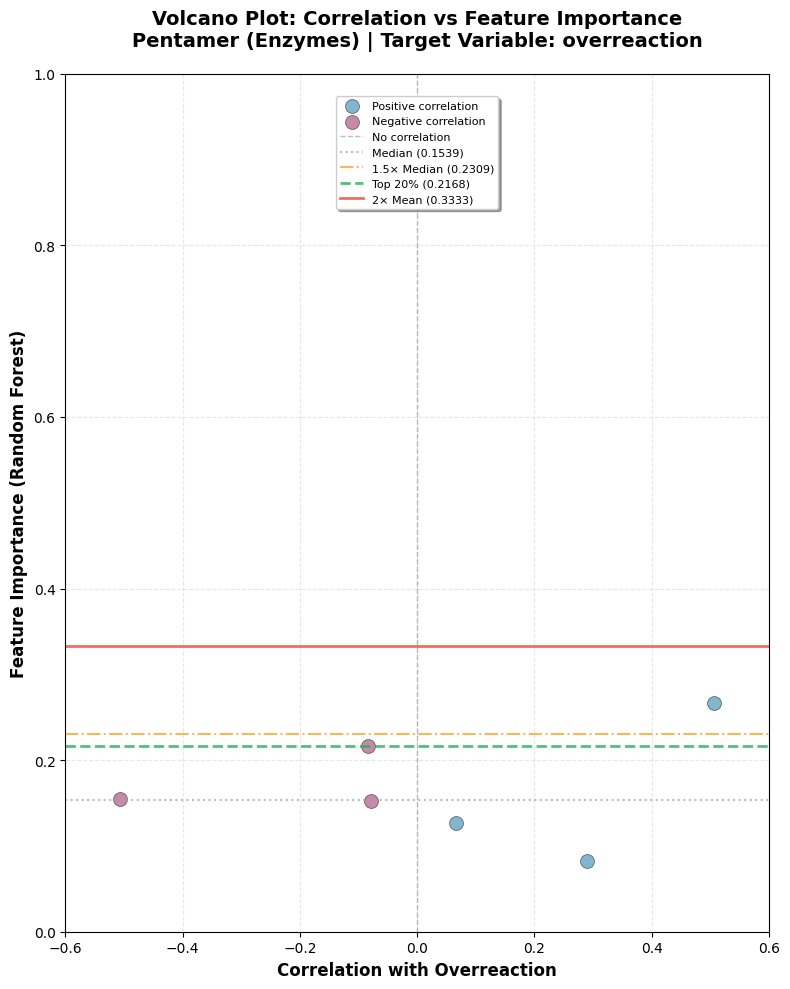


Top 10 features that INCREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
0,1,0.267038,0.506317,FAKE_deprot,"[Ub5_10, Ub5_11, Ub5_12, Ub5_13, Ub5_14, Ub5_17, Ub5_18, Ub5_21, Ub5_22, Ub5_23, Ub5_24, Ub5_25, Ub5_26, Ub5_27, Ub5...","[dimer_deprotection, tetramer_deprotection, trimer_deprotection]"
4,5,0.126314,0.065569,Ube2K,"[Ub5_10, Ub5_12, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_22, Ub5_23, Ub5_24, Ub5_25, Ub5_26, Ub5...","[pentamer_formation, tetramer_formation, trimer_formation]"
5,4,0.081901,0.289647,Ubc13/Mms2 (branching),"[Ub5_10, Ub5_11, Ub5_13, Ub5_21, Ub5_22, Ub5_26, Ub5_3, Ub5_4, Ub5_5, Ub5_8, Ub5_9]","[pentamer_formation, tetramer_formation, trimer_formation]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns
1,6,0.216848,-0.084428,gp78/Ube2g2,"[Ub5_1, Ub5_10, Ub5_11, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_22, Ub5_24, Ub5_2...","[dimer_formation, pentamer_formation, tetramer_formation, trimer_formation]"
2,2,0.154974,-0.506317,SMAC_deprot,"[Ub5_1, Ub5_10, Ub5_11, Ub5_12, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_2...","[dimer_deprotection, tetramer_deprotection, trimer_deprotection]"
3,3,0.152925,-0.078442,Ubc13/Mms2,"[Ub5_11, Ub5_12, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_22, Ub5_23, Ub5_24, Ub5_...","[dimer_formation, pentamer_formation, tetramer_formation, trimer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,original_value,parent synthetic pathways,matching_columns



PIPELINE COMPLETE


✓ Completed: ms5_enzymes_overreaction

Running: Multimer Size 5 | Analysis Mode: donors | Target: yield

STARTING PIPELINE

[1/8] Configuration...
   Config: Pentamer (Donors), target=yield, shape=(42, 12)

[2/8] Cleaning data...
   Cleaned: (42, 8)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (42, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 2
   High importance (>2× mean): 1

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms5_donors_yield.pdf


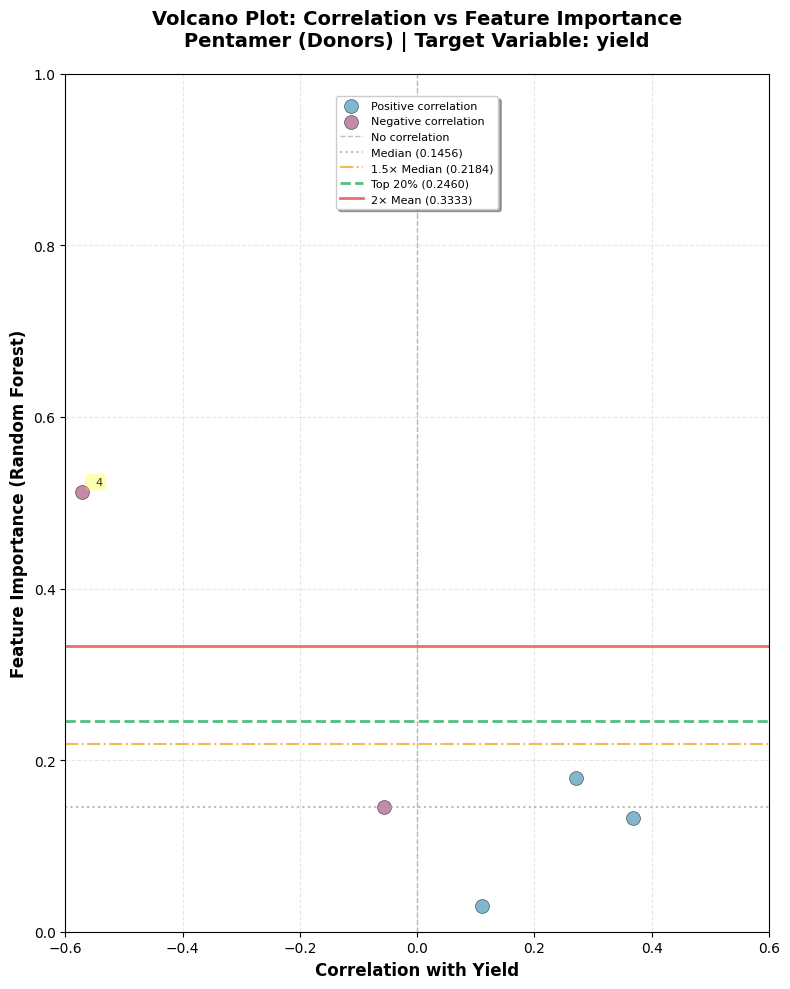


Top 10 features that INCREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
1,3,0.179346,0.270545,[],"[[1, K63], [1, K48]]","[Ub5_1, Ub5_10, Ub5_11, Ub5_12, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_2...","[dimer_formation, pentamer_formation, tetramer_formation, trimer_formation]"
3,6,0.132803,0.367489,"[[1, K63]]","[[1, K48]]","[Ub5_11, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_22, Ub5_23, Ub5_25, Ub5_27, Ub5_...","[dimer_formation, tetramer_formation, trimer_formation]"
4,2,0.029779,0.111025,"[[1, K48]]",[],"[Ub5_10, Ub5_11, Ub5_12, Ub5_3, Ub5_31, Ub5_4, Ub5_8]","[dimer_formation, trimer_formation]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,4,0.512439,-0.571896,"[[1, K48]]","[[1, K63]]","[Ub5_1, Ub5_10, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_18, Ub5_19, Ub5_2, Ub5_22, Ub5_24, Ub5_25, Ub5_27, Ub5_29, Ub5_3...","[dimer_formation, tetramer_formation, trimer_formation]"
2,5,0.145632,-0.056498,"[[1, K63]]",[],"[Ub5_17, Ub5_26, Ub5_32, Ub5_35, Ub5_36, Ub5_37, Ub5_40]","[dimer_formation, trimer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,4,0.512439,-0.571896,"[[1, K48]]","[[1, K63]]","[Ub5_1, Ub5_10, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_18, Ub5_19, Ub5_2, Ub5_22, Ub5_24, Ub5_25, Ub5_27, Ub5_29, Ub5_3...","[dimer_formation, tetramer_formation, trimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms5_donors_yield

Running: Multimer Size 5 | Analysis Mode: donors | Target: overreaction

STARTING PIPELINE

[1/8] Configuration...
   Config: Pentamer (Donors), target=overreaction, shape=(42, 12)

[2/8] Cleaning data...
   Cleaned: (42, 8)

[3/8] Collecting unique values...
   Found 6 unique values

[4/8] Encoding features...
   Encoded 6 features

[5/8] Creating feature count matrix...
   Created count matrix: (42, 7)

[6/8] Merging with band intensity data...
   Merged 1 sheets

[7/8] Training Random Forest models...
   Trained models for 1 sheets

[8/8] Enriching features with original values and correlations...
   Enriched 6 features
   Top positive: 3, Top negative: 2
   High importance (>2× mean): 1

[9/9] Generating volcano plot...
   Volcano plot and table saved to: /Users/ekummelstedt/le_code_base/ubiquitinformatics/back_end/revisions/volcano_plots/volcano_plot_ms5_donors_overreaction.pdf


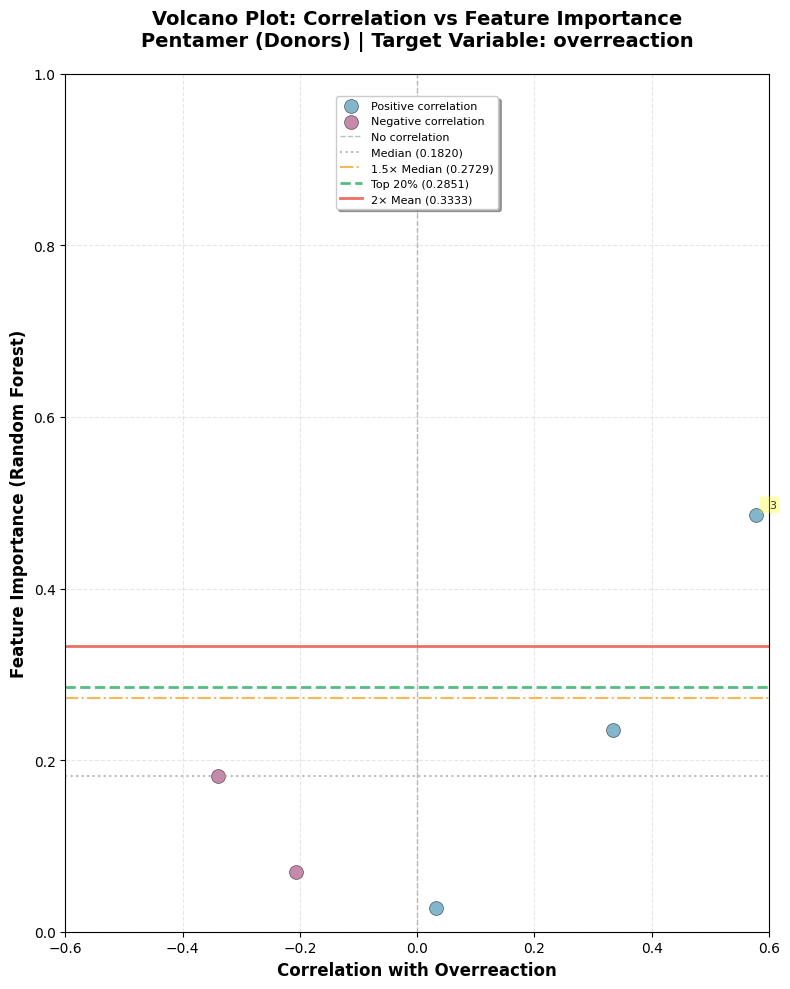


Top 10 features that INCREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,3,0.485965,0.577486,[],"[[1, K63], [1, K48]]","[Ub5_1, Ub5_10, Ub5_11, Ub5_12, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_2...","[dimer_formation, pentamer_formation, tetramer_formation, trimer_formation]"
1,2,0.234829,0.333257,"[[1, K48]]",[],"[Ub5_10, Ub5_11, Ub5_12, Ub5_3, Ub5_31, Ub5_4, Ub5_8]","[dimer_formation, trimer_formation]"
4,5,0.027077,0.032253,"[[1, K63]]",[],"[Ub5_17, Ub5_26, Ub5_32, Ub5_35, Ub5_36, Ub5_37, Ub5_40]","[dimer_formation, trimer_formation]"



Top 10 features that DECREASE the target:


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
2,4,0.181958,-0.339587,"[[1, K48]]","[[1, K63]]","[Ub5_1, Ub5_10, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_18, Ub5_19, Ub5_2, Ub5_22, Ub5_24, Ub5_25, Ub5_27, Ub5_29, Ub5_3...","[dimer_formation, tetramer_formation, trimer_formation]"
3,6,0.070171,-0.206579,"[[1, K63]]","[[1, K48]]","[Ub5_11, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_22, Ub5_23, Ub5_25, Ub5_27, Ub5_...","[dimer_formation, tetramer_formation, trimer_formation]"



Top 10 High importance features (above 2× mean):


,feature,importance,correlation,SMAC_lysines,ABOC_lysines,parent synthetic pathways,matching_columns
0,3,0.485965,0.577486,[],"[[1, K63], [1, K48]]","[Ub5_1, Ub5_10, Ub5_11, Ub5_12, Ub5_13, Ub5_14, Ub5_15, Ub5_16, Ub5_17, Ub5_18, Ub5_19, Ub5_2, Ub5_20, Ub5_21, Ub5_2...","[dimer_formation, pentamer_formation, tetramer_formation, trimer_formation]"



PIPELINE COMPLETE


✓ Completed: ms5_donors_overreaction

ALL COMBINATIONS COMPLETE - 12 PDFs generated


In [54]:
# Run all combinations of configurations to generate PDFs
# This will create 16 PDFs (2 multimer sizes × 4 analysis modes × 2 target variables)

all_results = {}

for multimer_size in [4, 5]:
    for analysis_mode in ['topology_with_PG', 'topology_only', 'enzymes', 'donors']:
        for target_variable in ['yield', 'overreaction']:
            print(f"\n{'='*100}")
            print(f"Running: Multimer Size {multimer_size} | Analysis Mode: {analysis_mode} | Target: {target_variable}")
            print(f"{'='*100}\n")
            
            try:
                results = run_ubiquitin_ml_pipeline(
                    multimer_size=multimer_size,
                    analysis_mode=analysis_mode,
                    target_variable=target_variable,
                    verbose=True
                )
                
                # Store results
                key = f"ms{multimer_size}_{analysis_mode}_{target_variable}"
                all_results[key] = results
                
                print(f"\n✓ Completed: {key}")
                
            except Exception as e:
                print(f"\n✗ Error with {key}: {str(e)}")
                continue

print(f"\n{'='*100}")
print(f"ALL COMBINATIONS COMPLETE - {len(all_results)} PDFs generated")
print(f"{'='*100}")